# Zenodo v2 — DDPM B2 Conditional PPG Generation
**Architecture:** 4-level U-Net · base_ch=64 · AdaGN conditioning · **Cosine schedule T=1000**  
**Samplers evaluated:** Ancestral (T=1000) · DDIM (100 steps)  
**Conditioning (B2):** IBI_mean · IBI_std · RMSSD · rhythm label (AF=+1, SR=−1)  
**All validation paradigms compare both samplers side-by-side**

---
Sections: §0 Setup · §1 Splits · §2 Assembly · §3 Normalisation · §4 Dataset  
§5 Model · §6 DDPM Training · §7 Samplers · §8 Spectral · §9 Physiological  
§10 Statistical + NN-PRD + Cond.Fidelity · §11 Part A In-Domain  
§12 Part B MIMIC-AF · §13 Part C VitalDB · §14 Part D MIMIC-III-Ext · §15 Summary


## §0 — Setup

In [4]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', pkg, '-q',
        '--upgrade-strategy', 'only-if-needed'
    ])

install('wfdb')
install('neurokit2')

In [5]:
import os, warnings, random, time, copy, math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from scipy.signal import butter, filtfilt, welch, find_peaks, resample_poly
from scipy.stats import wasserstein_distance, pearsonr
from sklearn.manifold import TSNE
from sklearn.metrics import (roc_auc_score, f1_score, precision_score,
                              accuracy_score, confusion_matrix)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import rbf_kernel
import h5py, glob
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed(SEED)

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()
amp_scaler = torch.cuda.amp.GradScaler(
    enabled=USE_AMP, init_scale=128,
    growth_factor=2.0, backoff_factor=0.5, growth_interval=1000)
torch.backends.cudnn.benchmark = True
print(f"Device: {DEVICE}  AMP: {'ON' if USE_AMP else 'OFF'}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATA_DIR  = Path("/kaggle/input/datasets/vegatronxz/zenodo-v2/zenodo_v2")
WORK_DIR  = Path("/kaggle/working"); WORK_DIR.mkdir(exist_ok=True)
CKPT_PATH = WORK_DIR / "best_ddpm_b2_zenodo.pt"

TEST_SET ='/kaggle/input/datasets/vegatronxz/best-models-final/zenodo_data/zenodo_b2_test.npz'
TRAIN_SET = '/kaggle/input/datasets/vegatronxz/best-models-final/zenodo_data/zenodo_b2_train.npz'
VAL_SET = '/kaggle/input/datasets/vegatronxz/best-models-final/zenodo_data/zenodo_b2_val.npz'

# Signal constants (same as CFM)
ECG_FS=500; PPG_FS_RAW=100; FS=125; WIN_SEC=10; WIN_LEN=FS*WIN_SEC
PAD_LEN=(256-WIN_LEN%256)%256; WIN_LEN_PAD=WIN_LEN+PAD_LEN
IBI_MIN=0.30; IBI_MAX=2.00

# Conditioning (same as CFM B2)
RAW_COND_DIM=4; RHYTHM_SIGN={'AF':+1.0,'SR':-1.0}

# Model (same as CFM)
BASE_CH=64; T_DIM=256; COND_DIM=128

# ── DDPM-specific ─────────────────────────────────────────────────────────────
T_DDPM    = 1000          # diffusion steps
N_DDIM    = 100           # DDIM steps at inference
N_ANCS    = T_DDPM        # ancestral steps (full)

# Training
BATCH_SIZE=256; LR=1e-4; WEIGHT_DECAY=1e-3; EPOCHS=80
EMA_DECAY=0.999; CFG_DROP=0.10; CAP=600

# Evaluation
ODE_STEPS=100; N_EVAL=300; N_TSNE=200

print(f"WIN_LEN={WIN_LEN}  PAD={PAD_LEN}  model_input={WIN_LEN_PAD}")
print(f"T_DDPM={T_DDPM}  N_DDIM={N_DDIM}  CAP={CAP}")


Device: cuda  AMP: ON
GPU: Tesla T4
WIN_LEN=1250  PAD=30  model_input=1280
T_DDPM=1000  N_DDIM=100  CAP=600


## §1 — Subject splits
**Excluded:** 028 (corrupted HDF5) · 029 (PPG unusable) · 042 (PPG unusable)  
**Cat A** — AF ≥ 200 windows → contributes both AF and SR windows  
**Cat B** — AF < 200 windows → contributes SR windows only  
Stratified 17/2/2 split within each category. SEED=0 chosen for balanced test coverage.


In [6]:
CAT_A = [1,2,4,6,8,11,12,17,18,19,20,21,23,27,32,34,37,41,43,44,45]  # 21 subjects
CAT_B = [3,5,7,9,10,13,14,15,16,22,24,25,26,30,31,33,35,36,38,39,40] # 21 subjects

random.seed(SEED)
cat_a = CAT_A.copy(); random.shuffle(cat_a)
cat_b = CAT_B.copy(); random.shuffle(cat_b)

TRAIN_A, VAL_A, TEST_A = cat_a[:17], cat_a[17:19], cat_a[19:]
TRAIN_B, VAL_B, TEST_B = cat_b[:17], cat_b[17:19], cat_b[19:]

TRAIN_SIDS = sorted(TRAIN_A + TRAIN_B)
VAL_SIDS   = sorted(VAL_A   + VAL_B)
TEST_SIDS  = sorted(TEST_A  + TEST_B)

print(f"TRAIN ({len(TRAIN_SIDS)}): {TRAIN_SIDS}")
print(f"  Cat A: {sorted(TRAIN_A)}")
print(f"  Cat B: {sorted(TRAIN_B)}")
print(f"VAL   ({len(VAL_SIDS)}):   {VAL_SIDS}")
print(f"  Cat A: {sorted(VAL_A)}  Cat B: {sorted(VAL_B)}")
print(f"TEST  ({len(TEST_SIDS)}):  {TEST_SIDS}")
print(f"  Cat A: {sorted(TEST_A)}  Cat B: {sorted(TEST_B)}")


TRAIN (34): [1, 3, 4, 5, 6, 8, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 21, 25, 26, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45]
  Cat A: [1, 4, 6, 8, 11, 12, 17, 19, 20, 21, 32, 34, 37, 41, 43, 44, 45]
  Cat B: [3, 5, 10, 13, 14, 15, 16, 25, 26, 30, 31, 33, 35, 36, 38, 39, 40]
VAL   (4):   [2, 7, 18, 24]
  Cat A: [2, 18]  Cat B: [7, 24]
TEST  (4):  [9, 22, 23, 27]
  Cat A: [23, 27]  Cat B: [9, 22]


## §2 — Dataset assembly
For each subject:
1. Load ECG HDF5 → QRS timestamps · AF annotations · RR intervals  
2. For each PPG segment → align to ECG timeline by absolute `t0_sec`  
3. Segment into 10s windows → label by majority AF beat vote  
4. Extract ECG-derived IBI_mean · IBI_std · RMSSD per window  
5. PPG quality filter (variance + finite check)  
6. Resample PPG 100 Hz → 125 Hz · min-max normalise to [−1, 1]  
7. Apply per-class cap = 2000 windows/subject  

Results cached to disk as `.npz` to avoid re-processing (≈ 5–6 h on first run).


In [7]:
# ── HDF5 helpers ─────────────────────────────────────────────────────────────
def ecg_path(sid): return DATA_DIR / f"{sid:03d}_ECG.mat"
def ppg_path(sid): return DATA_DIR / f"{sid:03d}_PPG.mat"

def decode_ascii(arr):
    try:
        return ''.join(chr(int(c)) for c in np.array(arr).flatten() if int(c) != 0).strip()
    except Exception:
        return ''

def timestamp_to_seconds(day_str, time_str):
    try:
        day   = int(day_str.strip()) if day_str.strip().isdigit() else 1
        parts = time_str.strip().split(':')
        h = int(parts[0]) if len(parts) > 0 else 0
        m = int(parts[1]) if len(parts) > 1 else 0
        s = int(parts[2]) if len(parts) > 2 else 0
        return (day - 1) * 86400 + h * 3600 + m * 60 + s
    except Exception:
        return None

def load_ecg(sid):
    with h5py.File(ecg_path(sid), 'r') as f:
        sig      = np.array(f['ECG']).squeeze().astype(np.float32)
        qrs      = np.array(f['QRSindex']).squeeze().astype(int)
        af       = np.array(f['AF_annotation']).squeeze().astype(int)
        rr       = np.array(f['rr']).squeeze().astype(np.float64)
        day_str  = decode_ascii(f['recording_startday'])
        time_str = decode_ascii(f['recording_starttime'])
    qrs = qrs[:len(af)]   # off-by-one fix: N beats, N-1 RR intervals
    t0  = timestamp_to_seconds(day_str, time_str)
    if t0 is None:
        raise ValueError(f"S{sid:03d}: invalid ECG timestamp")
    return dict(sig=sig, fs=ECG_FS, qrs=qrs, af=af, rr=rr, t0_sec=t0)

def load_ppg_segments(sid):
    segments = []
    with h5py.File(ppg_path(sid), 'r') as f:
        ppg_refs  = f['PPG_GREEN']
        day_refs  = f['recording_startday']
        time_refs = f['recording_starttime']
        for i in range(ppg_refs.shape[0]):
            sig      = np.array(f[ppg_refs[i,0]]).squeeze().astype(np.float32)
            day_str  = decode_ascii(f[day_refs[i,0]])
            time_str = decode_ascii(f[time_refs[i,0]])
            t0       = timestamp_to_seconds(day_str, time_str)
            if t0 is None:
                continue
            segments.append(dict(sig=sig, fs=PPG_FS_RAW, t0_sec=t0,
                                 n_samples=len(sig), seg_idx=i))
    return segments

# ── PPG preprocessing ─────────────────────────────────────────────────────────
_B4, _A4 = butter(4, [0.5/(PPG_FS_RAW/2), 8./(PPG_FS_RAW/2)], btype='band')
WIN_SAMP_RAW = WIN_SEC * PPG_FS_RAW  # 1000 samples at 100 Hz

def preprocess_ppg(win_raw):
    """Bandpass → resample 100→125 Hz → min-max [−1, 1]. Returns None if invalid."""
    if not np.all(np.isfinite(win_raw)) or np.all(win_raw == win_raw[0]):
        return None
    filt = filtfilt(_B4, _A4, win_raw.astype(float))
    if np.std(filt) < 1e-4:
        return None
    sig125 = resample_poly(filt, FS, PPG_FS_RAW)[:WIN_LEN]  # 100→125 Hz
    if len(sig125) < WIN_LEN:
        return None
    mn, mx = sig125.min(), sig125.max()
    if mx - mn < 1e-8:
        return None
    return (2*(sig125 - mn)/(mx - mn) - 1).astype(np.float32)

# ── ECG feature extraction per window ────────────────────────────────────────
def ecg_features_window(rr_window):
    """IBI_mean, IBI_std, RMSSD from ECG RR intervals in one 10s window."""
    rr = rr_window[(rr_window >= IBI_MIN) & (rr_window <= IBI_MAX)]
    if len(rr) < 3:
        return None, None, None
    ibi_mean = float(np.mean(rr))
    ibi_std  = float(np.std(rr))
    rmssd    = float(np.sqrt(np.mean(np.diff(rr)**2)))
    hr       = 60. / ibi_mean
    if not (30 < hr < 200):
        return None, None, None
    return ibi_mean, ibi_std, rmssd

# ── Per-subject processing ────────────────────────────────────────────────────
def process_subject(sid, cap=CAP):
    try:
        ecg  = load_ecg(sid)
        segs = load_ppg_segments(sid)
    except Exception as e:
        return None, f"load error: {e}"

    qrs_t_abs = ecg['qrs'] / ecg['fs'] + ecg['t0_sec']
    wins = {'AF': [], 'SR': []}  # (ppg_sig, ibi_mean, ibi_std, rmssd)

    for seg in segs:
        sig = seg['sig'].astype(float)
        t0  = seg['t0_sec']
        n_wins = len(sig) // WIN_SAMP_RAW

        for i in range(n_wins):
            if len(wins['AF']) >= cap and len(wins['SR']) >= cap:
                break
            s0      = i * WIN_SAMP_RAW
            t_start = t0 + s0 / PPG_FS_RAW
            t_end   = t_start + WIN_SEC

            beat_mask = (qrs_t_abs >= t_start) & (qrs_t_abs < t_end)
            beat_idx  = np.where(beat_mask)[0]
            if len(beat_idx) < 4:
                continue

            # Label: majority vote on AF annotation
            af_frac = ecg['af'][beat_idx].mean()
            rhythm  = 'AF' if af_frac > 0.5 else 'SR'
            if len(wins[rhythm]) >= cap:
                continue

            # ECG features
            rr_win = ecg['rr'][beat_idx]
            ibi_m, ibi_s, rmssd = ecg_features_window(rr_win)
            if ibi_m is None:
                continue

            # PPG preprocessing
            ppg = preprocess_ppg(sig[s0:s0+WIN_SAMP_RAW])
            if ppg is None:
                continue

            wins[rhythm].append((ppg, ibi_m, ibi_s, rmssd))

    n_af, n_sr = len(wins['AF']), len(wins['SR'])
    if n_af + n_sr == 0:
        return None, "no valid windows"

    all_ppg, all_ibi_m, all_ibi_s, all_rmssd, all_rhythm = [], [], [], [], []
    for rhythm, wlist in wins.items():
        for ppg, ibi_m, ibi_s, rmssd in wlist:
            all_ppg.append(ppg)
            all_ibi_m.append(ibi_m)
            all_ibi_s.append(ibi_s)
            all_rmssd.append(rmssd)
            all_rhythm.append(rhythm)

    return {
        'signals'   : np.array(all_ppg,   dtype=np.float32),
        'ibi_mean'  : np.array(all_ibi_m, dtype=np.float32),
        'ibi_std'   : np.array(all_ibi_s, dtype=np.float32),
        'rmssd'     : np.array(all_rmssd, dtype=np.float32),
        'rhythm'    : np.array(all_rhythm),
        'n_af'      : n_af,
        'n_sr'      : n_sr,
        'sid'       : sid,
    }, None

# ── Build or load split .npz files ───────────────────────────────────────────
def build_split(sids, split_name):
    cache = WORK_DIR / f"zenodo_b2_{split_name}.npz"
    if cache.exists():
        print(f"  Loading {split_name} from cache ({cache.stat().st_size/1e6:.1f} MB)")
        d = dict(np.load(cache, allow_pickle=True))
        print(f"  {len(d['rhythm'])} windows  "
              f"AF={( d['rhythm']=='AF').sum()}  "
              f"SR={(d['rhythm']=='SR').sum()}")
        return d

    print(f"\nBuilding {split_name} ({len(sids)} subjects)...")
    parts = {k: [] for k in ['signals','ibi_mean','ibi_std','rmssd','rhythm']}

    for sid in sorted(sids):
        result, err = process_subject(sid)
        if result is None:
            print(f"  S{sid:03d}: {err}"); continue
        for k in parts:
            parts[k].append(result[k])
        print(f"  S{sid:03d}: AF={result['n_af']:5d}  SR={result['n_sr']:5d}")

    data = {k: np.concatenate(v) for k, v in parts.items() if v}
    np.savez_compressed(cache, **data)
    n_af = (data['rhythm']=='AF').sum()
    n_sr = (data['rhythm']=='SR').sum()
    print(f"  → {len(data['rhythm'])} windows  AF={n_af}  SR={n_sr}")
    print(f"  Saved: {cache}")
    return data

df_train = build_split(TRAIN_SIDS, 'train')
df_val   = build_split(VAL_SIDS,   'val')
df_test  = build_split(TEST_SIDS,  'test')



Building train (34 subjects)...
  S001: AF=  600  SR=  600
  S003: AF=    1  SR=  600
  S004: AF=  600  SR=  600
  S005: AF=  192  SR=  600
  S006: AF=  600  SR=  600
  S008: AF=  600  SR=  600
  S010: AF=  159  SR=  600
  S011: AF=  496  SR=  600
  S012: AF=  600  SR=  600
  S013: AF=   75  SR=  600
  S014: AF=    0  SR=  600
  S015: AF=    0  SR=  600
  S016: AF=    1  SR=  600
  S017: AF=  600  SR=  600
  S019: AF=  600  SR=  600
  S020: AF=  600  SR=  600
  S021: AF=  600  SR=  600
  S025: AF=    2  SR=  600
  S026: AF=    0  SR=  600
  S030: AF=    0  SR=  600
  S031: AF=    0  SR=  600
  S032: AF=  600  SR=  600
  S033: AF=    1  SR=  600
  S034: AF=  600  SR=  600
  S035: AF=    0  SR=  600
  S036: AF=   87  SR=  600
  S037: AF=  600  SR=  600
  S038: AF=    0  SR=  600
  S039: AF=    0  SR=  600
  S040: AF=    1  SR=  600
  S041: AF=  600  SR=  600
  S043: AF=  600  SR=  600
  S044: AF=  600  SR=  600
  S045: AF=   11  SR=  600
  → 30426 windows  AF=10026  SR=20400
  Saved: /k

In [8]:
#Celula para depois da prineira Run e guardados osresultados dos datasets de train/val/test
#não ter de correr outra vez a celula em cima.
#Descomentar se for usar

#from pathlib import Path

## Diretório de entrada no Kaggle onde os ficheiros .npz já existem
#DATA_DIR = Path("/kaggle/input/datasets/vegatronxz/best-models-final/zenodo_data")

## ── Build or load split .npz files ───────────────────────────────────────────
#def build_split(sids, split_name):
    ## Procura primeiro na pasta do Kaggle Input
    #cache = DATA_DIR / f"zenodo_b2_{split_name}.npz"
    
    #if cache.exists():
        #print(f"  Loading {split_name} from cache ({cache.stat().st_size/1e6:.1f} MB)")
        #d = dict(np.load(cache, allow_pickle=True))
        #print(f"  {len(d['rhythm'])} windows  "
         #     f"AF={(d['rhythm']=='AF').sum()}  "
         #    f"SR={(d['rhythm']=='SR').sum()}")
        #return d

    ## Caso não encontre no DATA_DIR, tenta no WORK_DIR local
    #cache_work = WORK_DIR / f"zenodo_b2_{split_name}.npz"
    #if cache_work.exists():
        #print(f"  Loading {split_name} from WORK_DIR ({cache_work.stat().st_size/1e6:.1f} MB)")
        #d = dict(np.load(cache_work, allow_pickle=True))
        #return d

    ## Se não existir em nenhum lado, constrói do zero e guarda em WORK_DIR
    #print(f"\nBuilding {split_name} ({len(sids)} subjects)...")
    #parts = {k: [] for k in ['signals', 'ibi_mean', 'ibi_std', 'rmssd', 'rhythm']}

    #for sid in sorted(sids):
        #result, err = process_subject(sid)
        #if result is None:
            #print(f"  S{sid:03d}: {err}"); continue
        #for k in parts:
            #parts[k].append(result[k])
        #print(f"  S{sid:03d}: AF={result['n_af']:5d}  SR={result['n_sr']:5d}")

    #data = {k: np.concatenate(v) for k, v in parts.items() if v}
    #np.savez_compressed(cache_work, **data)
    #n_af = (data['rhythm'] == 'AF').sum()
    #n_sr = (data['rhythm'] == 'SR').sum()
    #print(f"  → {len(data['rhythm'])} windows  AF={n_af}  SR={n_sr}")
    #print(f"  Saved: {cache_work}")
    #return data

#df_train = build_split(TRAIN_SIDS, 'train')
#df_val   = build_split(VAL_SIDS,   'val')
#df_test  = build_split(TEST_SIDS,  'test')

## §3 — IBI/RMSSD normalisation + statistics

In [9]:
# Z-score normalisation from train set only (same as MIMIC v5)
def _stats(data, mask):
    return float(data[mask].mean()), float(data[mask].std()) + 1e-8

tr_af = df_train['rhythm'] == 'AF'
tr_sr = df_train['rhythm'] == 'SR'
tr_all = np.ones(len(df_train['rhythm']), dtype=bool)

IBI_MEAN_MU,  IBI_MEAN_STD  = _stats(df_train['ibi_mean'], tr_all)
IBI_STD_MU,   IBI_STD_STD   = _stats(df_train['ibi_std'],  tr_all)
RMSSD_MU,     RMSSD_STD     = _stats(df_train['rmssd'],    tr_all)

print(f"IBI_mean  μ={IBI_MEAN_MU:.4f}  σ={IBI_MEAN_STD:.4f}")
print(f"IBI_std   μ={IBI_STD_MU:.4f}   σ={IBI_STD_STD:.4f}")
print(f"RMSSD     μ={RMSSD_MU:.4f}     σ={RMSSD_STD:.4f}")

def norm_ibi(ibi_mean, ibi_std, rmssd):
    nm = (np.asarray(ibi_mean) - IBI_MEAN_MU) / IBI_MEAN_STD
    ns = (np.asarray(ibi_std)  - IBI_STD_MU)  / IBI_STD_STD
    nr = (np.asarray(rmssd)    - RMSSD_MU)    / RMSSD_STD
    return nm.astype(np.float32), ns.astype(np.float32), nr.astype(np.float32)

def build_cond(nm, ns, nr, rhythm):
    """Build 4D conditioning vector. rhythm: array of 'AF'/'SR' strings."""
    sign = np.array([RHYTHM_SIGN[r] for r in rhythm], dtype=np.float32)
    return np.stack([nm, ns, nr, sign], axis=1)  # (N, 4)

# Dataset statistics
print()
print(f"{'Split':6s}  {'N':>7}  {'N_AF':>6}  {'N_SR':>6}  "
      f"{'IBI_m(AF)':>12}  {'RMSSD(AF)':>11}  {'IBI_m(SR)':>12}  {'RMSSD(SR)':>11}")
print("─" * 82)
for name, d in [('Train',df_train),('Val',df_val),('Test',df_test)]:
    af = d['rhythm']=='AF'; sr = d['rhythm']=='SR'
    print(f"{name:6s}  {len(d['rhythm']):>7}  {af.sum():>6}  {sr.sum():>6}  "
          f"{d['ibi_mean'][af].mean():>8.3f}±{d['ibi_mean'][af].std():>5.3f}  "
          f"{d['rmssd'][af].mean():>7.3f}±{d['rmssd'][af].std():>5.3f}  "
          f"{d['ibi_mean'][sr].mean():>8.3f}±{d['ibi_mean'][sr].std():>5.3f}  "
          f"{d['rmssd'][sr].mean():>7.3f}±{d['rmssd'][sr].std():>5.3f}")


IBI_mean  μ=0.8118  σ=0.2075
IBI_std   μ=0.1017   σ=0.0959
RMSSD     μ=0.1443     σ=0.1459

Split         N    N_AF    N_SR     IBI_m(AF)    RMSSD(AF)     IBI_m(SR)    RMSSD(SR)
──────────────────────────────────────────────────────────────────────────────────
Train     30426   10026   20400     0.656±0.185    0.223±0.100     0.888±0.172    0.106±0.149
Val        3602    1202    2400     0.623±0.177    0.231±0.097     0.943±0.213    0.095±0.121
Test       3649    1249    2400     0.672±0.157    0.192±0.074     0.874±0.144    0.122±0.160


## §4 — PPGDataset & DataLoaders

In [10]:
class PPGDataset(Dataset):
    LABEL = {'SR': 0, 'AF': 1}

    def __init__(self, data):
        rhythms = data['rhythm']
        nm, ns, nr = norm_ibi(data['ibi_mean'], data['ibi_std'], data['rmssd'])
        self.cond    = torch.from_numpy(build_cond(nm, ns, nr, rhythms))  # (N,4)
        # Zero-pad 1250 → 1280 (divisible by 4^4 = 256 for 4-level stride-4 U-Net)
        sigs = data['signals']                                             # (N,1250)
        if PAD_LEN > 0:
            sigs = np.pad(sigs, ((0,0),(0,PAD_LEN)), mode='constant')     # (N,1280)
        self.signals = torch.from_numpy(sigs).unsqueeze(1)                # (N,1,1280)
        self.labels  = torch.tensor(
            [self.LABEL[r] for r in rhythms], dtype=torch.long)
        self.af_idx  = np.where(rhythms == 'AF')[0]
        self.sr_idx  = np.where(rhythms == 'SR')[0]

    def __len__(self):
        return 2 * min(len(self.af_idx), len(self.sr_idx))

    def __getitem__(self, idx):
        n = min(len(self.af_idx), len(self.sr_idx))
        i = self.af_idx[np.random.randint(len(self.af_idx))] if idx < n \
            else self.sr_idx[np.random.randint(len(self.sr_idx))]
        return self.signals[i], self.cond[i], self.labels[i]

# Unbalanced datasets for val, test
class PPGDatasetFull(Dataset):
    LABEL = {'SR': 0, 'AF': 1}
    def __init__(self, data):
        rhythms = data['rhythm']
        nm, ns, nr = norm_ibi(data['ibi_mean'], data['ibi_std'], data['rmssd'])
        self.cond   = torch.from_numpy(build_cond(nm, ns, nr, rhythms))
        sigs = data['signals']
        if PAD_LEN > 0:
            sigs = np.pad(sigs, ((0,0),(0,PAD_LEN)), mode='constant')
        self.signals = torch.from_numpy(sigs).unsqueeze(1)
        self.labels  = torch.tensor([self.LABEL[r] for r in rhythms], dtype=torch.long)
    def __len__(self): return len(self.labels)
    def __getitem__(self, i): return self.signals[i], self.cond[i], self.labels[i]

ds_train = PPGDataset(df_train)
ds_val   = PPGDatasetFull(df_val)
ds_test  = PPGDatasetFull(df_test)

dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                      num_workers=2, pin_memory=True, drop_last=True)
dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)
dl_test  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                      num_workers=2, pin_memory=True)

print(f"Train: {len(ds_train)} balanced samples  ({len(dl_train)} batches)")
print(f"Val  : {len(ds_val)} samples  ({len(dl_val)} batches)")
print(f"Test : {len(ds_test)} samples  ({len(dl_test)} batches)")
print(f"Signal shape: {ds_train[0][0].shape}  (1, {WIN_LEN_PAD})")


Train: 20052 balanced samples  (78 batches)
Val  : 3602 samples  (15 batches)
Test : 3649 samples  (15 batches)
Signal shape: torch.Size([1, 1280])  (1, 1280)


## §5b — Cosine noise schedule (T=1000)

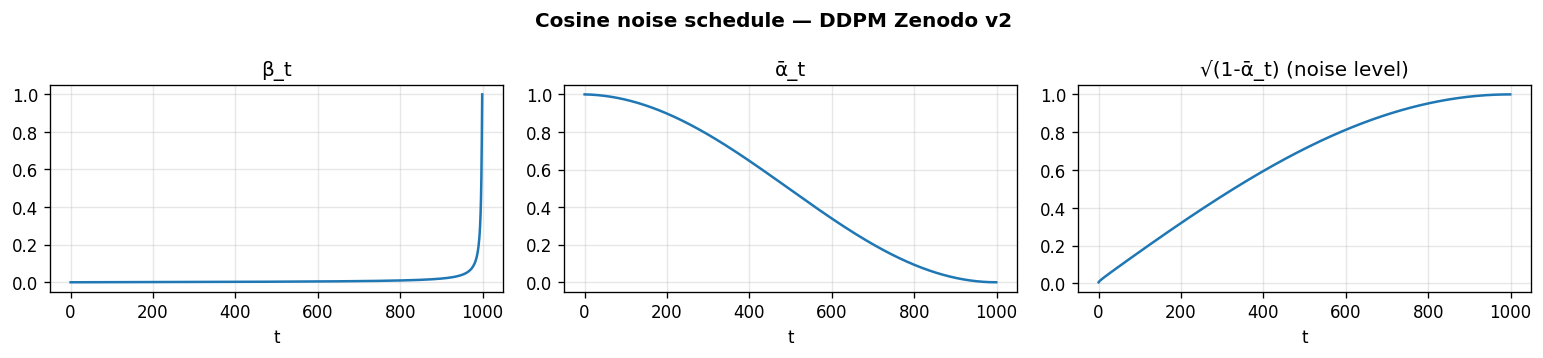

Cosine schedule built.
  β range: [0.000041, 0.999000]
  ᾱ_T    : 0.000000  (→ 0 = pure noise)


In [11]:
def make_cosine_schedule(T=T_DDPM, s=0.008, device=DEVICE):
    steps     = torch.arange(T+1, dtype=torch.float64)
    f         = torch.cos(((steps/T + s)/(1+s)) * math.pi/2)**2
    acp       = f / f[0]                          # ᾱ_t  (alphas_cumprod)
    betas     = (1 - acp[1:]/acp[:-1]).clamp(0, 0.999).float()
    alphas    = 1 - betas
    acp       = torch.cumprod(alphas, dim=0).to(device)
    return {
        'betas'                       : betas.to(device),
        'alphas'                      : alphas.to(device),
        'alphas_cumprod'              : acp,
        'sqrt_alphas_cumprod'         : acp.sqrt(),
        'sqrt_one_minus_alphas_cumprod': (1-acp).sqrt(),
    }

NS = make_cosine_schedule()

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(13, 3))
t_ax = torch.arange(T_DDPM).cpu()
axes[0].plot(t_ax, NS['betas'].cpu());             axes[0].set_title('β_t');       axes[0].set_xlabel('t')
axes[1].plot(t_ax, NS['alphas_cumprod'].cpu());    axes[1].set_title('ᾱ_t');      axes[1].set_xlabel('t')
axes[2].plot(t_ax, NS['sqrt_one_minus_alphas_cumprod'].cpu()); axes[2].set_title('√(1-ᾱ_t) (noise level)'); axes[2].set_xlabel('t')
for ax in axes: ax.grid(alpha=0.3)
plt.suptitle('Cosine noise schedule — DDPM Zenodo v2', fontweight='bold')
plt.tight_layout(); plt.savefig(WORK_DIR/'fig_schedule.png', dpi=150); plt.show()
print("Cosine schedule built.")
print(f"  β range: [{NS['betas'].min():.6f}, {NS['betas'].max():.6f}]")
print(f"  ᾱ_T    : {NS['alphas_cumprod'][-1]:.6f}  (→ 0 = pure noise)")


## §5 — UNet1D with AdaGN (identical to CFM B2 — only training objective changes)

In [12]:
def sinusoidal_embedding(t, dim):
    half=dim//2
    freqs=torch.exp(-torch.arange(half,device=t.device,dtype=torch.float32)*(np.log(10000)/(half-1)))
    args=t[:,None].float()*freqs[None]*1000
    return torch.cat([args.sin(),args.cos()],dim=-1)

class AdaGN(nn.Module):
    def __init__(self,ch,emb_dim,groups=8):
        super().__init__()
        g=min(groups,ch); self.gn=nn.GroupNorm(g,ch)
        self.scale=nn.Linear(emb_dim,ch); self.shift=nn.Linear(emb_dim,ch)
        nn.init.zeros_(self.scale.weight); nn.init.ones_(self.scale.bias)
        nn.init.zeros_(self.shift.weight); nn.init.zeros_(self.shift.bias)
    def forward(self,x,emb):
        s=self.scale(emb)[:,:,None]; b=self.shift(emb)[:,:,None]
        return self.gn(x)*(1+s)+b

class ResBlock(nn.Module):
    def __init__(self,ch,emb_dim,k=5,dropout=0.05):
        super().__init__()
        p=k//2; self.c1=nn.Conv1d(ch,ch,k,padding=p); self.c2=nn.Conv1d(ch,ch,k,padding=p)
        self.a1=AdaGN(ch,emb_dim); self.a2=AdaGN(ch,emb_dim)
        self.act=nn.SiLU(); self.drop=nn.Dropout(dropout)
    def forward(self,x,emb):
        h=self.act(self.a1(self.c1(x),emb)); h=self.drop(h); h=self.a2(self.c2(h),emb)
        return self.act(x+h)

class EmbSeq(nn.Module):
    def __init__(self,*blocks): super().__init__(); self.blocks=nn.ModuleList(blocks)
    def forward(self,x,emb):
        for b in self.blocks: x=b(x,emb)
        return x

class UNet1D(nn.Module):
    def __init__(self,base_ch=BASE_CH,t_dim=T_DIM,cond_dim=COND_DIM):
        super().__init__()
        ch=base_ch; emb=t_dim+cond_dim
        self.t_proj=nn.Sequential(nn.Linear(t_dim,t_dim),nn.SiLU(),nn.Linear(t_dim,t_dim))
        self.c_proj=nn.Sequential(nn.Linear(RAW_COND_DIM,cond_dim),nn.SiLU(),nn.Linear(cond_dim,cond_dim))
        self.in_conv=nn.Conv1d(1,ch,7,padding=3)
        self.d1=EmbSeq(ResBlock(ch,emb),ResBlock(ch,emb));     self.p1=nn.Conv1d(ch,ch*2,4,stride=4)
        self.d2=EmbSeq(ResBlock(ch*2,emb),ResBlock(ch*2,emb)); self.p2=nn.Conv1d(ch*2,ch*4,4,stride=4)
        self.d3=EmbSeq(ResBlock(ch*4,emb),ResBlock(ch*4,emb)); self.p3=nn.Conv1d(ch*4,ch*8,4,stride=4)
        self.d4=EmbSeq(ResBlock(ch*8,emb),ResBlock(ch*8,emb)); self.p4=nn.Conv1d(ch*8,ch*8,4,stride=4)
        self.mid=EmbSeq(ResBlock(ch*8,emb),ResBlock(ch*8,emb))
        self.u4=nn.ConvTranspose1d(ch*8,ch*8,4,stride=4);  self.up4=EmbSeq(ResBlock(ch*16,emb),ResBlock(ch*16,emb))
        self.u3=nn.ConvTranspose1d(ch*16,ch*4,4,stride=4); self.up3=EmbSeq(ResBlock(ch*8,emb),ResBlock(ch*8,emb))
        self.u2=nn.ConvTranspose1d(ch*8,ch*2,4,stride=4);  self.up2=EmbSeq(ResBlock(ch*4,emb),ResBlock(ch*4,emb))
        self.u1=nn.ConvTranspose1d(ch*4,ch,4,stride=4);    self.up1=EmbSeq(ResBlock(ch*2,emb),ResBlock(ch*2,emb))
        self.out=nn.Conv1d(ch*2,1,1)
    def _pad(self,x,n):
        if x.shape[-1]<n: x=F.pad(x,(0,n-x.shape[-1]))
        return x[...,:n]
    def forward(self,x,t,cond):
        t_emb=self.t_proj(sinusoidal_embedding(t,T_DIM)); c_emb=self.c_proj(cond); emb=torch.cat([t_emb,c_emb],-1)
        h=self.in_conv(x)
        s1=self.d1(h,emb);  h=self.p1(s1)
        s2=self.d2(h,emb);  h=self.p2(s2)
        s3=self.d3(h,emb);  h=self.p3(s3)
        s4=self.d4(h,emb);  h=self.p4(s4)
        h=self.mid(h,emb)
        h=self.u4(h);       h=self._pad(h,s4.shape[-1]); h=self.up4(torch.cat([h,s4],1),emb)
        h=self.u3(h);       h=self._pad(h,s3.shape[-1]); h=self.up3(torch.cat([h,s3],1),emb)
        h=self.u2(h);       h=self._pad(h,s2.shape[-1]); h=self.up2(torch.cat([h,s2],1),emb)
        h=self.u1(h);       h=self._pad(h,s1.shape[-1]); h=self.up1(torch.cat([h,s1],1),emb)
        return self.out(h)

model=UNet1D().to(DEVICE); ema_model=copy.deepcopy(model).eval()
for p in ema_model.parameters(): p.requires_grad_(False)
n_par=sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"UNet1D DDPM — {n_par:,} parameters  (base_ch={BASE_CH})")
_x=torch.randn(4,1,WIN_LEN_PAD).to(DEVICE); _t=torch.rand(4).to(DEVICE); _c=torch.randn(4,RAW_COND_DIM).to(DEVICE)
print(f"Forward check: {tuple(_x.shape)} → {tuple(model(_x,_t,_c).shape)}"); del _x,_t,_c


UNet1D DDPM — 54,860,225 parameters  (base_ch=64)
Forward check: (4, 1, 1280) → (4, 1, 1280)


## §6 — DDPM Training (ε-prediction · cosine schedule · CFG dropout · EMA)

Training DDPM — 80 epochs | AMP ON | batch=256 | 78 batches/epoch
──────────────────────────────────────────────────────────────────────
  ep=  1  tr=0.2863  val=2.0124  val_SR=2.0252  val_AF=1.9869  t=0.9min ✓
  ep=  5  tr=0.0563  val=0.3357  val_SR=0.3379  val_AF=0.3313  t=4.1min ✓
  ep= 10  tr=0.0402  val=0.1309  val_SR=0.1284  val_AF=0.1359  t=8.2min ✓
  ep= 15  tr=0.0379  val=0.0988  val_SR=0.0983  val_AF=0.0996  t=12.4min ✓
  ep= 20  tr=0.0360  val=0.0752  val_SR=0.0726  val_AF=0.0804  t=16.5min ✓
  ep= 25  tr=0.0335  val=0.0604  val_SR=0.0591  val_AF=0.0630  t=20.6min ✓
  ep= 30  tr=0.0330  val=0.0531  val_SR=0.0524  val_AF=0.0546  t=24.7min ✓
  ep= 35  tr=0.0318  val=0.0463  val_SR=0.0449  val_AF=0.0491  t=28.9min ✓
  ep= 40  tr=0.0316  val=0.0422  val_SR=0.0411  val_AF=0.0444  t=33.0min ✓
  ep= 45  tr=0.0316  val=0.0364  val_SR=0.0351  val_AF=0.0390  t=37.1min ✓
  ep= 50  tr=0.0312  val=0.0334  val_SR=0.0323  val_AF=0.0355  t=41.2min ✓
  ep= 55  tr=0.0307  val=0.0319  val_SR=0

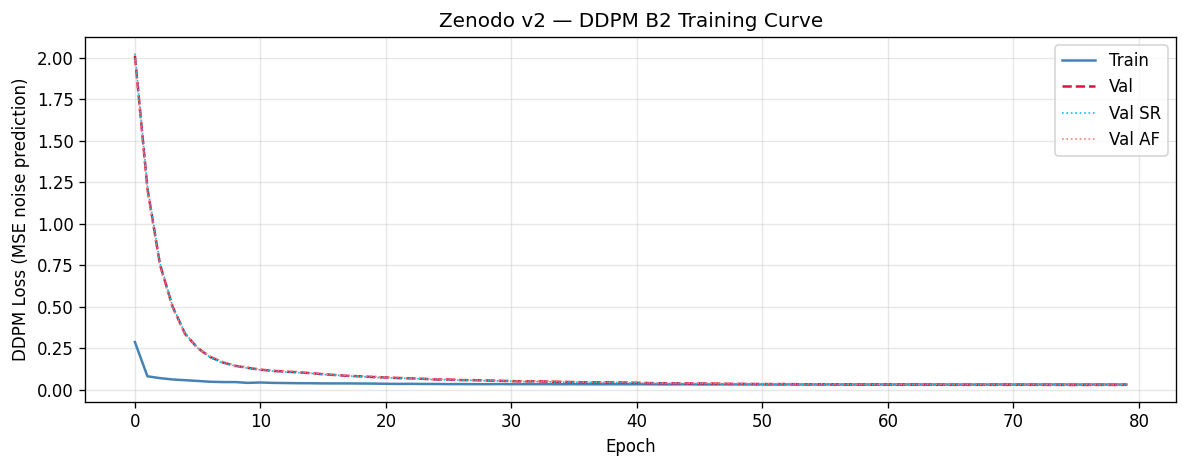

Best val loss: 0.0277


In [13]:
def ddpm_loss(mdl, x0, cond, cfg_drop=CFG_DROP):
    """DDPM ε-prediction loss with classifier-free guidance dropout."""    
    B     = x0.shape[0]
    t_int = torch.randint(0, T_DDPM, (B,), device=x0.device)         # integer t
    t_norm= t_int.float() / (T_DDPM - 1)                             # normalised to [0,1]
    noise = torch.randn_like(x0)
    # Forward diffusion q(x_t | x_0)
    sqrt_acp  = NS['sqrt_alphas_cumprod'][t_int].view(B,1,1)
    sqrt_omacp= NS['sqrt_one_minus_alphas_cumprod'][t_int].view(B,1,1)
    x_t   = sqrt_acp * x0 + sqrt_omacp * noise
    # CFG dropout
    mask      = (torch.rand(B, device=x0.device) < cfg_drop).float()
    cond_in   = cond * (1 - mask.unsqueeze(1))
    with torch.cuda.amp.autocast(enabled=USE_AMP):
        eps_pred = mdl(x_t, t_norm, cond_in)
    return F.mse_loss(eps_pred.float(), noise)

def update_ema(model, ema, decay=EMA_DECAY):
    with torch.no_grad():
        for p,ep in zip(model.parameters(),ema.parameters()):
            ep.data.mul_(decay).add_(p.data, alpha=1.0-decay)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

history={'train':[],'val':[],'val_sr':[],'val_af':[]}
best_val=float('inf'); t0_train=time.time()
print(f"Training DDPM — {EPOCHS} epochs | AMP {'ON' if USE_AMP else 'OFF'} | batch={BATCH_SIZE} | {len(dl_train)} batches/epoch")
print("─"*70)

for epoch in range(1, EPOCHS+1):
    model.train()
    tr_losses=[]
    for sig,cond,_ in dl_train:
        sig,cond=sig.to(DEVICE,non_blocking=True),cond.to(DEVICE,non_blocking=True)
        optimizer.zero_grad()
        loss=ddpm_loss(model,sig,cond)
        amp_scaler.scale(loss).backward()
        amp_scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(),1.0)
        amp_scaler.step(optimizer); amp_scaler.update()
        update_ema(model,ema_model); tr_losses.append(loss.item())
    scheduler.step()

    ema_model.eval(); vl,vl_sr,vl_af=[],[],[]
    with torch.no_grad():
        for sig,cond,lbl in dl_val:
            sig,cond=sig.to(DEVICE),cond.to(DEVICE)
            B2=sig.shape[0]; t_int=torch.randint(0,T_DDPM,(B2,),device=DEVICE)
            t_norm=t_int.float()/(T_DDPM-1)
            noise=torch.randn_like(sig)
            sqrt_acp=NS['sqrt_alphas_cumprod'][t_int].view(B2,1,1)
            sqrt_omacp=NS['sqrt_one_minus_alphas_cumprod'][t_int].view(B2,1,1)
            x_t=sqrt_acp*sig+sqrt_omacp*noise
            with torch.cuda.amp.autocast(enabled=USE_AMP):
                eps_p=ema_model(x_t,t_norm,cond)
            ps=F.mse_loss(eps_p.float(),noise,reduction='none').mean(dim=(1,2)).cpu().numpy()
            vl.extend(ps); vl_sr.extend(ps[lbl.numpy()==0]); vl_af.extend(ps[lbl.numpy()==1])

    tr_l=float(np.mean(tr_losses)); vl_l=float(np.mean(vl))
    history['train'].append(tr_l); history['val'].append(vl_l)
    history['val_sr'].append(float(np.mean(vl_sr)) if vl_sr else float('nan'))
    history['val_af'].append(float(np.mean(vl_af)) if vl_af else float('nan'))

    tag=''
    if vl_l<best_val:
        best_val=vl_l
        torch.save({'epoch':epoch,'val_loss':vl_l,'model':model.state_dict(),'ema_model':ema_model.state_dict(),
                    'ibi_mean_mu':IBI_MEAN_MU,'ibi_mean_std':IBI_MEAN_STD,
                    'ibi_std_mu':IBI_STD_MU,  'ibi_std_std':IBI_STD_STD,
                    'rmssd_mu':RMSSD_MU,'rmssd_std':RMSSD_STD}, CKPT_PATH)
        tag=' ✓'
    if epoch%5==0 or epoch==1:
        print(f"  ep={epoch:3d}  tr={tr_l:.4f}  val={vl_l:.4f}  val_SR={history['val_sr'][-1]:.4f}  val_AF={history['val_af'][-1]:.4f}  t={(time.time()-t0_train)/60:.1f}min{tag}")

fig,ax=plt.subplots(figsize=(10,4))
ax.plot(history['train'],label='Train',color='steelblue',lw=1.5)
ax.plot(history['val'],  label='Val',  color='crimson',  lw=1.5,ls='--')
ax.plot(history['val_sr'],label='Val SR',color='deepskyblue',lw=1,ls=':')
ax.plot(history['val_af'],label='Val AF',color='salmon',    lw=1,ls=':')
ax.set_xlabel('Epoch'); ax.set_ylabel('DDPM Loss (MSE noise prediction)')
ax.set_title('Zenodo v2 — DDPM B2 Training Curve'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(WORK_DIR/'fig_training_curve.png',dpi=150); plt.show()
print(f"Best val loss: {best_val:.4f}")


## §7 — Ancestral & DDIM Samplers + Guidance Scale Sweep

Loaded checkpoint — epoch 76  val_loss=0.0277
Guidance scale sweep (DDIM, fast)...
  gs=0.5  AF=8.383  SR=10.174  mean=9.278
  gs=1.0  AF=9.338  SR=9.663  mean=9.501
  gs=1.5  AF=7.768  SR=10.085  mean=8.927
  gs=2.0  AF=8.701  SR=9.483  mean=9.092
  gs=3.0  AF=7.465  SR=10.677  mean=9.071
  gs=5.0  AF=8.126  SR=11.012  mean=9.569

✓ Best guidance scale (shared for both samplers): 1.5


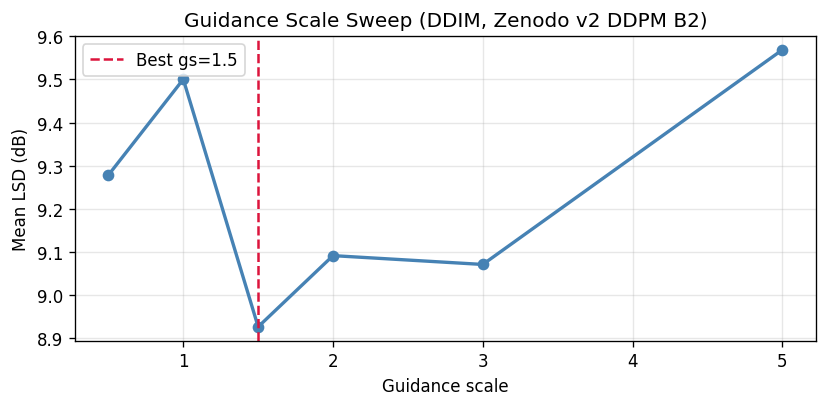

In [31]:
ckpt=torch.load(CKPT_PATH,map_location=DEVICE,weights_only=False)
#ckpt=torch.load('/kaggle/input/datasets/vegatronxz/best-models-final/best_ddpm_zenodo.pt',map_location=DEVICE,weights_only=False)
ema_model.load_state_dict(ckpt['ema_model']); model.load_state_dict(ckpt['model']); model.eval()
print(f"Loaded checkpoint — epoch {ckpt['epoch']}  val_loss={ckpt['val_loss']:.4f}")

@torch.no_grad()
def ancestral_sample(mdl, cond, cfg_scale=1.0):
    """DDPM ancestral reverse process — T_DDPM steps."""    
    B=cond.size(0); x=torch.randn(B,1,WIN_LEN_PAD,device=DEVICE); null=torch.zeros_like(cond)
    for t_idx in reversed(range(T_DDPM)):
        t_norm=torch.full((B,),t_idx/(T_DDPM-1),device=DEVICE)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            eps_c=mdl(x,t_norm,cond); eps_u=mdl(x,t_norm,null)
        eps=eps_u+cfg_scale*(eps_c-eps_u)
        sqrt_acp=NS['sqrt_alphas_cumprod'][t_idx]; sqrt_omacp=NS['sqrt_one_minus_alphas_cumprod'][t_idx]
        x0_pred=((x-sqrt_omacp*eps)/sqrt_acp).clamp(-1.5,1.5)
        if t_idx>0:
            acp_t=NS['alphas_cumprod'][t_idx]; acp_tm1=NS['alphas_cumprod'][t_idx-1]
            beta_t=NS['betas'][t_idx]; alpha_t=NS['alphas'][t_idx]
            mu = (acp_tm1.sqrt()*beta_t/(1-acp_t))*x0_pred + (alpha_t.sqrt()*(1-acp_tm1)/(1-acp_t))*x
            var= beta_t*(1-acp_tm1)/(1-acp_t)
            x  = mu + var.sqrt()*torch.randn_like(x)
        else:
            x=x0_pred
    return x[...,:WIN_LEN].float()

@torch.no_grad()
def ddim_sample(mdl, cond, n_steps=N_DDIM, cfg_scale=1.0, eta=0.0):
    """DDIM deterministic reverse process — n_steps steps."""    
    B=cond.size(0); x=torch.randn(B,1,WIN_LEN_PAD,device=DEVICE); null=torch.zeros_like(cond)
    
    # Garantimos que os valores sejam inteiros para não partir a função range()
    t_ddpm_int = int(T_DDPM)
    n_steps_int = int(n_steps)
    c = int(t_ddpm_int // n_steps_int)
    
    ts = list(reversed(range(0, t_ddpm_int, c)))[:n_steps_int]
    
    for i,t_idx in enumerate(ts):
        t_norm=torch.full((B,),t_idx/(t_ddpm_int-1),device=DEVICE)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            eps_c=mdl(x,t_norm,cond); eps_u=mdl(x,t_norm,null)
        eps=eps_u+cfg_scale*(eps_c-eps_u)
        acp_t=NS['alphas_cumprod'][t_idx]
        x0_pred=((x-(1-acp_t).sqrt()*eps)/acp_t.sqrt()).clamp(-1.5,1.5)
        acp_prev=NS['alphas_cumprod'][ts[i+1]] if i<len(ts)-1 else torch.tensor(1.0,device=DEVICE)
        sigma=eta*((1-acp_prev)/(1-acp_t)*(1-acp_t/acp_prev)).sqrt()
        x=acp_prev.sqrt()*x0_pred+(1-acp_prev-sigma**2).clamp(0).sqrt()*eps
        if eta>0: x=x+sigma*torch.randn_like(x)
    return x[...,:WIN_LEN].float()

te_af=df_test['rhythm']=='AF'; te_sr=df_test['rhythm']=='SR'
def get_test_cond(rh,n):
    mask=te_af if rh=='AF' else te_sr; n=min(n,mask.sum())
    idx=np.random.choice(mask.sum(),n,replace=False)
    d={k:v[mask] for k,v in df_test.items() if hasattr(v,'__len__') and len(v)==len(mask)}
    nm,ns_v,nr=norm_ibi(d['ibi_mean'][idx],d['ibi_std'][idx],d['rmssd'][idx])
    cond=torch.tensor(build_cond(nm,ns_v,nr,np.full(len(idx),rh)),dtype=torch.float32).to(DEVICE)
    return cond, d['signals'][idx]

def lsd(real_b,synth_b,band=(0.5,8.0)):
    eps,vals,msk=1e-10,[],None
    for r,s in zip(real_b,synth_b):
        f,pr=welch(r,fs=FS,nperseg=512); _,ps=welch(s,fs=FS,nperseg=512)
        if msk is None: msk=(f>=band[0])&(f<=band[1])
        vals.append(np.sqrt(np.mean((10*np.log10(pr[msk]+eps)-10*np.log10(ps[msk]+eps))**2)))
    return float(np.nanmean(vals))

# ── Guidance scale sweep (DDIM — fast) ───────────────────────────────────────
GS_CANDS=[0.5,1.0,1.5,2.0,3.0,5.0]; N_SW=64; N_SW_STEPS=50
sw_cond={'AF':get_test_cond('AF',N_SW)[0],'SR':get_test_cond('SR',N_SW)[0]}
sw_real={'AF':get_test_cond('AF',N_SW)[1][:,:WIN_LEN],'SR':get_test_cond('SR',N_SW)[1][:,:WIN_LEN]}

print("Guidance scale sweep (DDIM, fast)...")
sweep_lsd={}
for gs in GS_CANDS:
    l=[]
    for rh in ['AF','SR']:
        syn=ddim_sample(ema_model,sw_cond[rh],n_steps=N_SW_STEPS,cfg_scale=gs).cpu().numpy().squeeze(1)
        l.append(lsd(sw_real[rh],syn))
    sweep_lsd[gs]=float(np.mean(l)); print(f"  gs={gs:.1f}  AF={l[0]:.3f}  SR={l[1]:.3f}  mean={sweep_lsd[gs]:.3f}")

BEST_GS=min(sweep_lsd,key=sweep_lsd.get); print(f"\n✓ Best guidance scale (shared for both samplers): {BEST_GS}")

fig,ax=plt.subplots(figsize=(7,3.5))
ax.plot(list(sweep_lsd.keys()),list(sweep_lsd.values()),'o-',color='steelblue',lw=2)
ax.axvline(BEST_GS,color='crimson',ls='--',label=f'Best gs={BEST_GS}')
ax.set_xlabel('Guidance scale'); ax.set_ylabel('Mean LSD (dB)')
ax.set_title('Guidance Scale Sweep (DDIM, Zenodo v2 DDPM B2)'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(WORK_DIR/'fig_gs_sweep.png',dpi=150); plt.show()


  Ancestral AF (300 windows × T=1000 steps)...
    done. shape=(300, 1250)
  Ancestral SR (300 windows × T=1000 steps)...
    done. shape=(300, 1250)
  ddim AF: 300 synthetic windows
  ancs AF: 300 synthetic windows
  ddim SR: 300 synthetic windows
  ancs SR: 300 synthetic windows


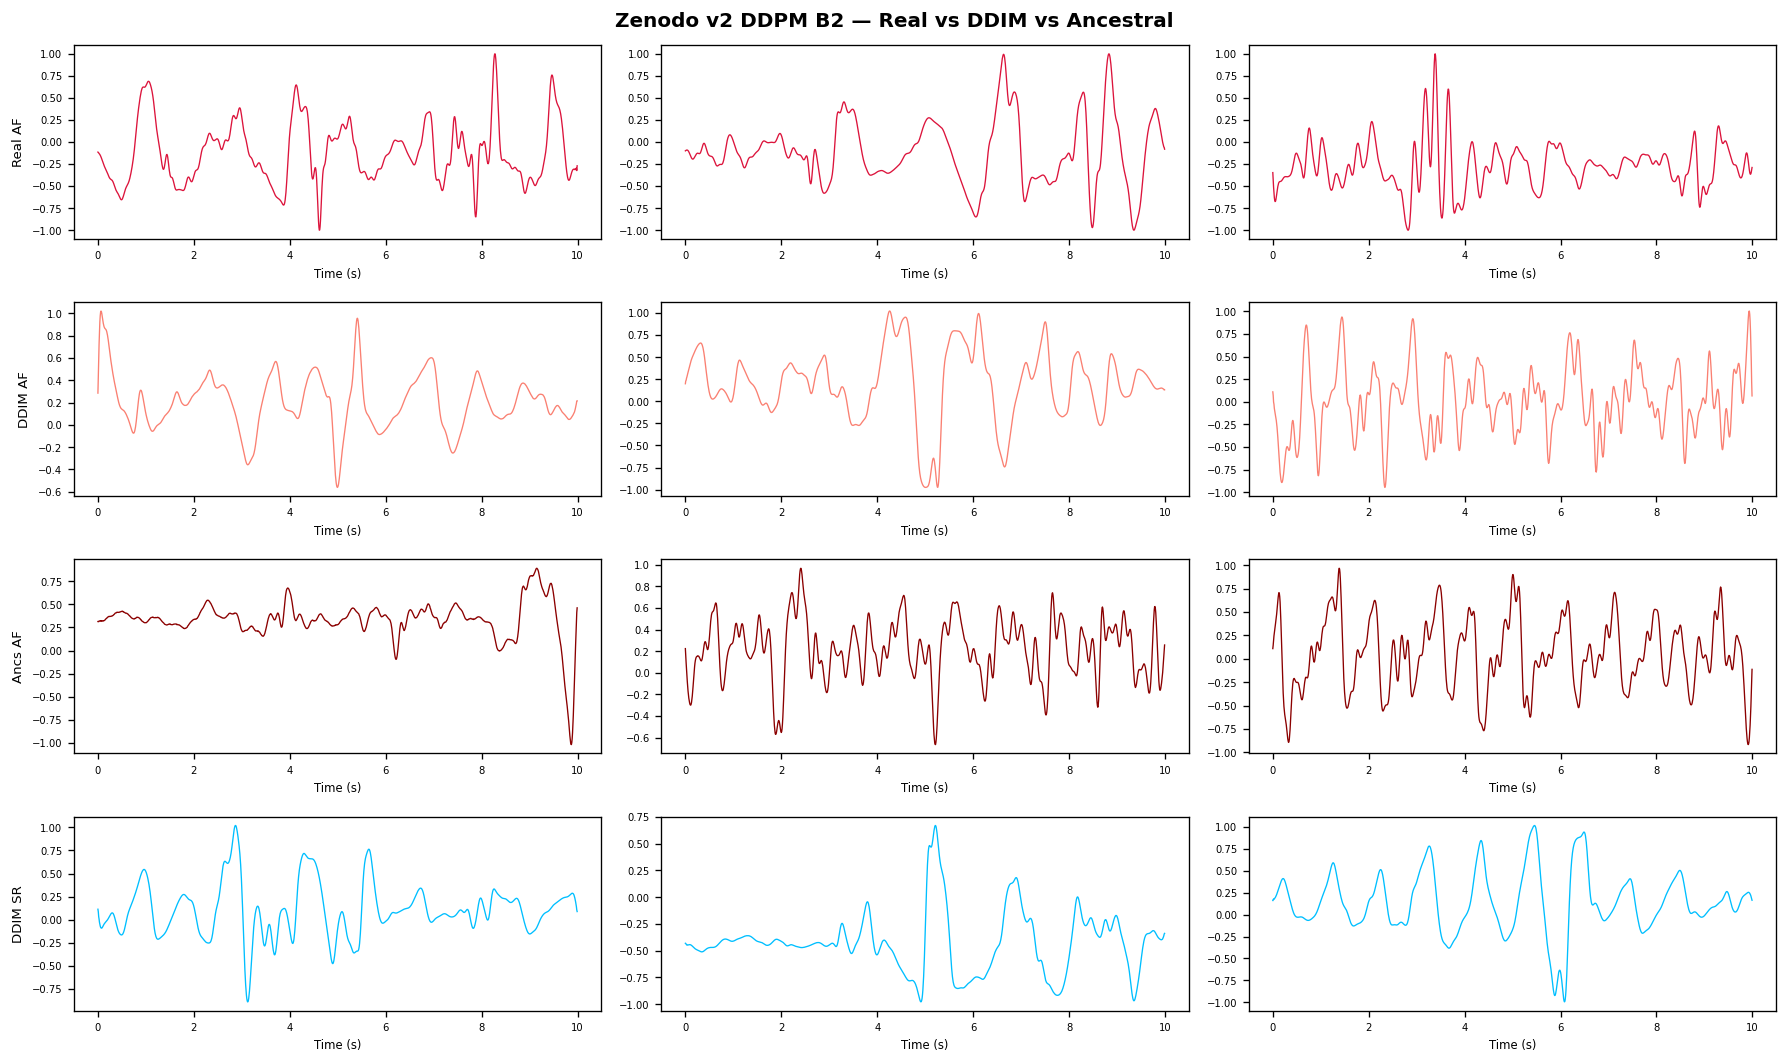

In [22]:
# ── Generate evaluation sets (N_EVAL per class, both samplers) ───────────────
eval_synth={'ancs':{},'ddim':{}}; eval_real={}

for rh,mask in [('AF',te_af),('SR',te_sr)]:
    n=min(N_EVAL,mask.sum())
    idx=np.random.choice(mask.sum(),n,replace=False)
    d={k:v[mask] for k,v in df_test.items() if hasattr(v,'__len__') and len(v)==len(mask)}
    nm,ns_v,nr=norm_ibi(d['ibi_mean'][idx],d['ibi_std'][idx],d['rmssd'][idx])
    cond=torch.tensor(build_cond(nm,ns_v,nr,np.full(len(idx),rh)),dtype=torch.float32).to(DEVICE)
    eval_real[rh]=d['signals'][idx]

    # DDIM (fast)
    out=[]
    for i in range(0,len(cond),64): out.append(ddim_sample(ema_model,cond[i:i+64],N_DDIM,BEST_GS).cpu().numpy().squeeze(1))
    eval_synth['ddim'][rh]=np.concatenate(out)

    # Ancestral (slow)
    print(f"  Ancestral {rh} ({n} windows × T={T_DDPM} steps)...")
    out=[]
    for i in range(0,len(cond),32):   # smaller batch for memory
        out.append(ancestral_sample(ema_model,cond[i:i+32],BEST_GS).cpu().numpy().squeeze(1))
    eval_synth['ancs'][rh]=np.concatenate(out)
    print(f"    done. shape={eval_synth['ancs'][rh].shape}")

for rh in ['AF','SR']:
    for samp in ['ddim','ancs']:
        print(f"  {samp} {rh}: {len(eval_synth[samp][rh])} synthetic windows")

# ── Visual generation (3 examples per class per sampler) ─────────────────────
fig,axes=plt.subplots(4,3,figsize=(15,9)); t_ax=np.arange(WIN_LEN)/FS
titles=[('Real AF','crimson',eval_real['AF']),
        ('DDIM AF','salmon', eval_synth['ddim']['AF']),
        ('Ancs AF','darkred',eval_synth['ancs']['AF']),
        ('DDIM SR','deepskyblue',eval_synth['ddim']['SR'])]
for row,(title,col,arr) in enumerate(titles):
    for col_i in range(3):
        axes[row,col_i].plot(t_ax,arr[col_i],lw=0.8,color=col)
        if col_i==0: axes[row,col_i].set_ylabel(title,fontsize=8)
        axes[row,col_i].set_xlabel('Time (s)',fontsize=7); axes[row,col_i].tick_params(labelsize=6)
plt.suptitle('Zenodo v2 DDPM B2 — Real vs DDIM vs Ancestral',fontweight='bold')
plt.tight_layout(); plt.savefig(WORK_DIR/'fig_visual.png',dpi=150); plt.show()


## §8 — Spectral Evaluation: DDIM vs Ancestral

=== SPECTRAL EVALUATION ===
  Sampler      LSD AF (dB)   LSD SR (dB)    LSD mean
  ────────────────────────────────────────────────
  DDIM-100          8.2512        8.8704      8.5608
  Ancestral         7.9837        8.5311      8.2574


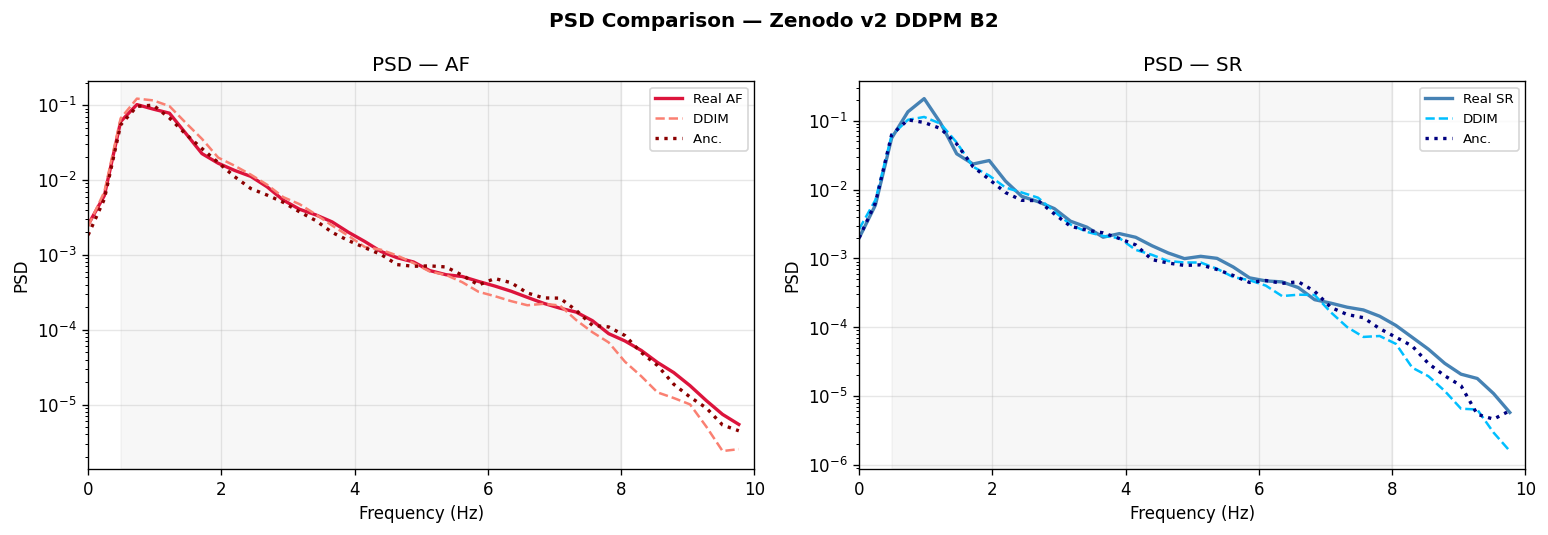

In [23]:
print("=== SPECTRAL EVALUATION ===")
print(f"  {'Sampler':<10}  {'LSD AF (dB)':>12}  {'LSD SR (dB)':>12}  {'LSD mean':>10}")
print("  " + "─" * 48)
lsd_results = {}
for samp, label in [('ddim', 'DDIM-100'), ('ancs', 'Ancestral')]:
    laf = lsd(eval_real['AF'], eval_synth[samp]['AF'])
    lsr = lsd(eval_real['SR'], eval_synth[samp]['SR'])
    lsd_results[samp] = {'AF': laf, 'SR': lsr, 'mean': (laf + lsr) / 2}
    print(f"  {label:<10}  {laf:>12.4f}  {lsr:>12.4f}  {(laf + lsr) / 2:>10.4f}")

# Figura com 1 linha e 2 colunas
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Configuração de estilos visualmente distintos para cada classe e sampler
styles = {
    'AF': {
        'real': {'color': 'crimson',   'ls': '-',  'lw': 2.0, 'label': 'Real AF'},
        'ddim': {'color': 'salmon',    'ls': '--', 'lw': 1.5, 'label': f'DDIM '},
        'ancs': {'color': 'darkred',   'ls': ':',  'lw': 2.0, 'label': f'Anc. '}
    },
    'SR': {
        'real': {'color': 'steelblue', 'ls': '-',  'lw': 2.0, 'label': 'Real SR'},
        'ddim': {'color': 'deepskyblue', 'ls': '--', 'lw': 1.5, 'label': f'DDIM'},
        'ancs': {'color': 'navy',      'ls': ':',  'lw': 2.0, 'label': f'Anc.'}
    }
}

for col, rh in enumerate(['AF', 'SR']):
    ax = axes[col]
    
    # Cálculo do PSD para o Sinal Real
    pr = []
    for r in eval_real[rh][:150]:
        _, p = welch(r, fs=FS, nperseg=512)
        pr.append(p)
    
    freq = np.linspace(0, FS / 2, len(pr[0]))
    msk_f = freq <= 10
    
    # Plot Real (Linha contínua)
    ax.semilogy(freq[msk_f], np.mean(pr, axis=0)[msk_f], **styles[rh]['real'])
    
    # Plot dos Samplers (DDIM em tracejado '--' e Ancestral em pontilhado ':')
    for samp in ['ddim', 'ancs']:
        ps = []
        for s in eval_synth[samp][rh][:150]:
            _, p = welch(s, fs=FS, nperseg=512)
            ps.append(p)
            
        ax.semilogy(freq[msk_f], np.mean(ps, axis=0)[msk_f], **styles[rh][samp])
        
    ax.axvspan(0.5, 8, alpha=0.06, color='grey')
    ax.set_xlim(0, 10)
    ax.set_xlabel('Frequency (Hz)')
    ax.set_ylabel('PSD')
    ax.set_title(f'PSD — {rh}')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.suptitle('PSD Comparison — Zenodo v2 DDPM B2', fontweight='bold')
plt.tight_layout()
plt.savefig(WORK_DIR / 'fig_psd.png', dpi=150)
plt.show()

## §9 — Physiological Consistency: DDIM vs Ancestral

Metric           Real AF       DDIM AF       Ancs AF       Real SR       DDIM SR       Ancs SR
──────────────────────────────────────────────────────────────────────────────────
  HR        81.277±22.140  86.855±19.043  92.731±23.330  78.625±23.211  85.755±21.731  92.837±23.700
  IBI_mean   0.797±0.235   0.725±0.165   0.693±0.191   0.831±0.241   0.750±0.211   0.695±0.204
  IBI_std    0.259±0.114   0.245±0.092   0.232±0.093   0.233±0.129   0.237±0.096   0.227±0.100
  RMSSD      0.390±0.178   0.347±0.144   0.333±0.150   0.347±0.208   0.330±0.154   0.327±0.156


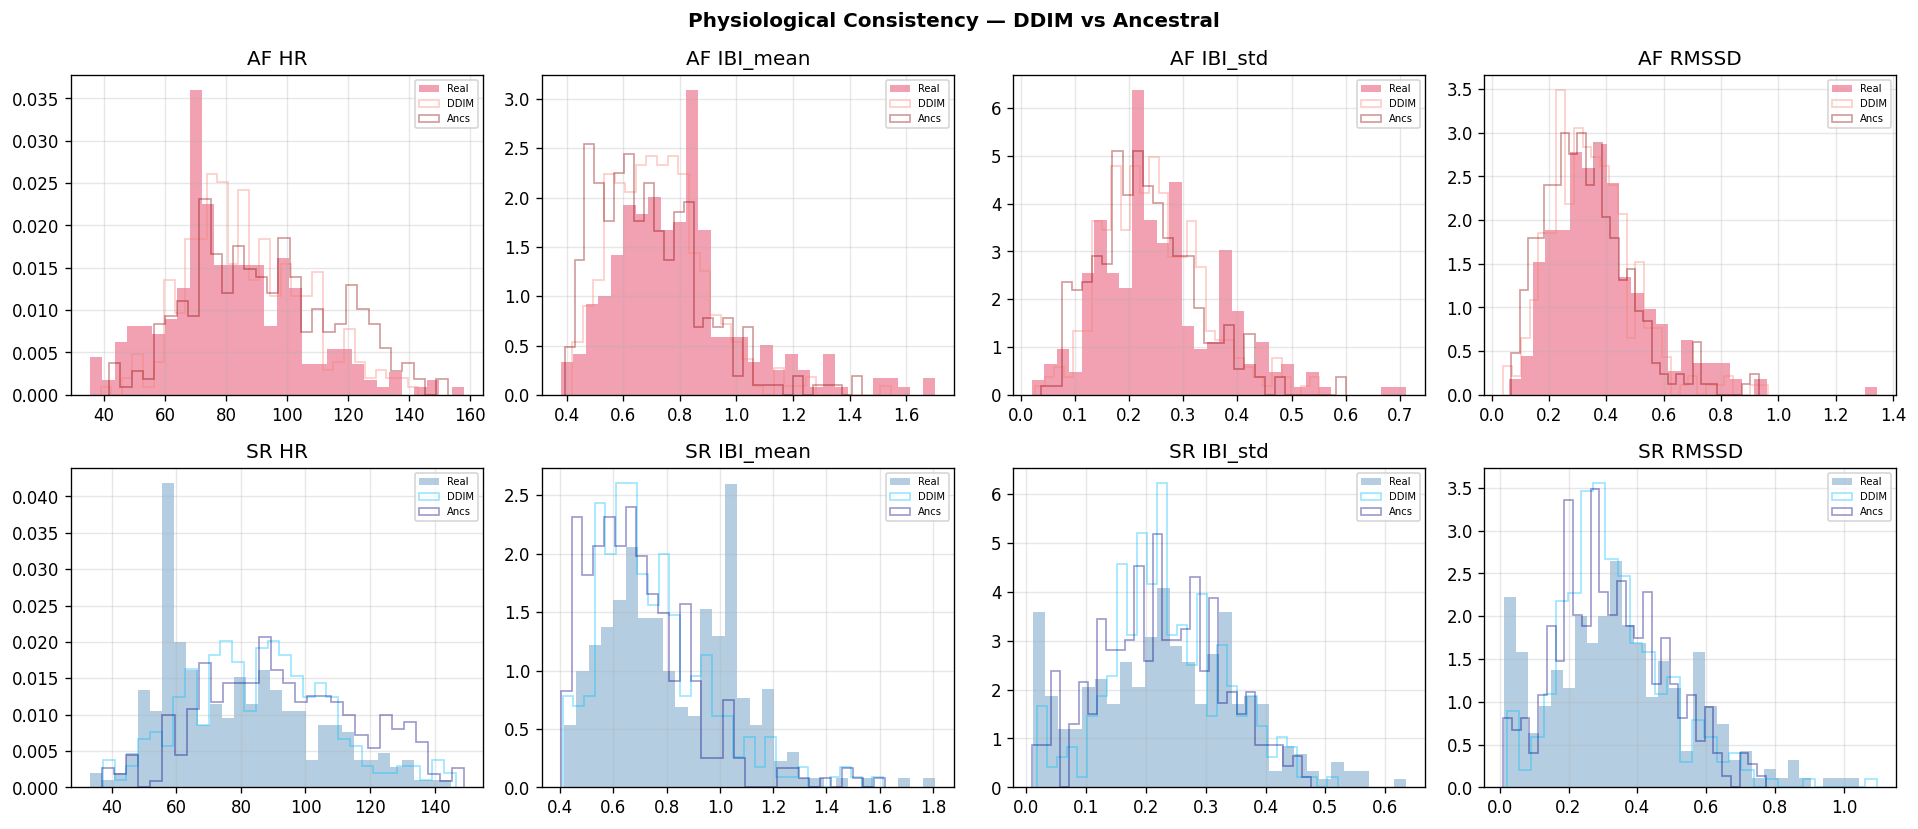

In [24]:
def ppg_phys(sig,fs=FS):
    try:
        peaks,_=find_peaks(sig,distance=int(fs*0.3),height=0.0)
        if len(peaks)<3: return (np.nan,)*4
        ibi=np.diff(peaks)/fs; ibi=ibi[(ibi>=IBI_MIN)&(ibi<=IBI_MAX)]
        if len(ibi)<2: return (np.nan,)*4
        hr=60./np.mean(ibi); rmssd=float(np.sqrt(np.mean(np.diff(ibi)**2))) if len(ibi)>=3 else np.nan
        return hr,float(np.mean(ibi)),float(np.std(ibi)),rmssd
    except: return (np.nan,)*4

phys_metrics={}
for key,arr_dict in [('real',eval_real),('ddim',eval_synth['ddim']),('ancs',eval_synth['ancs'])]:
    phys_metrics[key]={}
    for rh,arr in arr_dict.items():
        hrs,ibim,ibis,rmssds=[],[],[],[]
        for sig in arr:
            h,m,s,r=ppg_phys(sig)
            if not np.isnan(h): hrs.append(h);ibim.append(m);ibis.append(s);rmssds.append(r)
        phys_metrics[key][rh]={'HR':hrs,'IBI_mean':ibim,'IBI_std':ibis,'RMSSD':rmssds}

print(f"{'Metric':<10}  {'Real AF':>12}  {'DDIM AF':>12}  {'Ancs AF':>12}  {'Real SR':>12}  {'DDIM SR':>12}  {'Ancs SR':>12}")
print("─"*82)
for feat in ['HR','IBI_mean','IBI_std','RMSSD']:
    vals=[]
    for key,rh in [('real','AF'),('ddim','AF'),('ancs','AF'),('real','SR'),('ddim','SR'),('ancs','SR')]:
        v=[x for x in phys_metrics[key][rh][feat] if not np.isnan(x)]
        vals.append(f"{np.mean(v):.3f}±{np.std(v):.3f}" if v else "N/A")
    print(f"  {feat:<8}  {'  '.join(f'{v:>12}' for v in vals)}")

fig,axes=plt.subplots(2,4,figsize=(16,7))
for col,(feat,unit) in enumerate(zip(['HR','IBI_mean','IBI_std','RMSSD'],['bpm','s','s','s'])):
    for row,(rh,cr,cd,ca) in enumerate([('AF','crimson','salmon','darkred'),
                                         ('SR','steelblue','deepskyblue','navy')]):
        ax=axes[row,col]
        rv=[x for x in phys_metrics['real'][rh][feat] if not np.isnan(x)]
        dv=[x for x in phys_metrics['ddim'][rh][feat] if not np.isnan(x)]
        av=[x for x in phys_metrics['ancs'][rh][feat] if not np.isnan(x)]
        if rv: ax.hist(rv,bins=30,alpha=0.4,color=cr,density=True,label='Real')
        if dv: ax.hist(dv,bins=30,alpha=0.4,color=cd,density=True,label='DDIM',histtype='step',lw=2)
        if av: ax.hist(av,bins=30,alpha=0.4,color=ca,density=True,label='Ancs',histtype='step',lw=2,ls='--')
        ax.set_title(f'{rh} {feat}'); ax.legend(fontsize=6); ax.grid(alpha=0.3)
plt.suptitle('Physiological Consistency — DDIM vs Ancestral',fontweight='bold')
plt.tight_layout(); plt.savefig(WORK_DIR/'fig_phys.png',dpi=150); plt.show()


## §10 — Statistical Validation: DDIM vs Ancestral

Wasserstein distance (Real vs Synthetic):

  Sampler: DDIM-100
  Feature                  AF          SR
  ──────────────────────────────────────
    HR_mean            8.4011      9.2158
    HR_std             6.3796      4.4874
    Power_0-4Hz        0.0206      0.0352
    Power_4-8Hz        0.0008      0.0011
    RMS                0.0164      0.0201

  Sampler: Ancestral
  Feature                  AF          SR
  ──────────────────────────────────────
    HR_mean           11.6561     13.9030
    HR_std             5.7491      6.6894
    Power_0-4Hz        0.0073      0.0410
    Power_4-8Hz        0.0005      0.0009
    RMS                0.0145      0.0238

Computing t-SNE (6-way)...


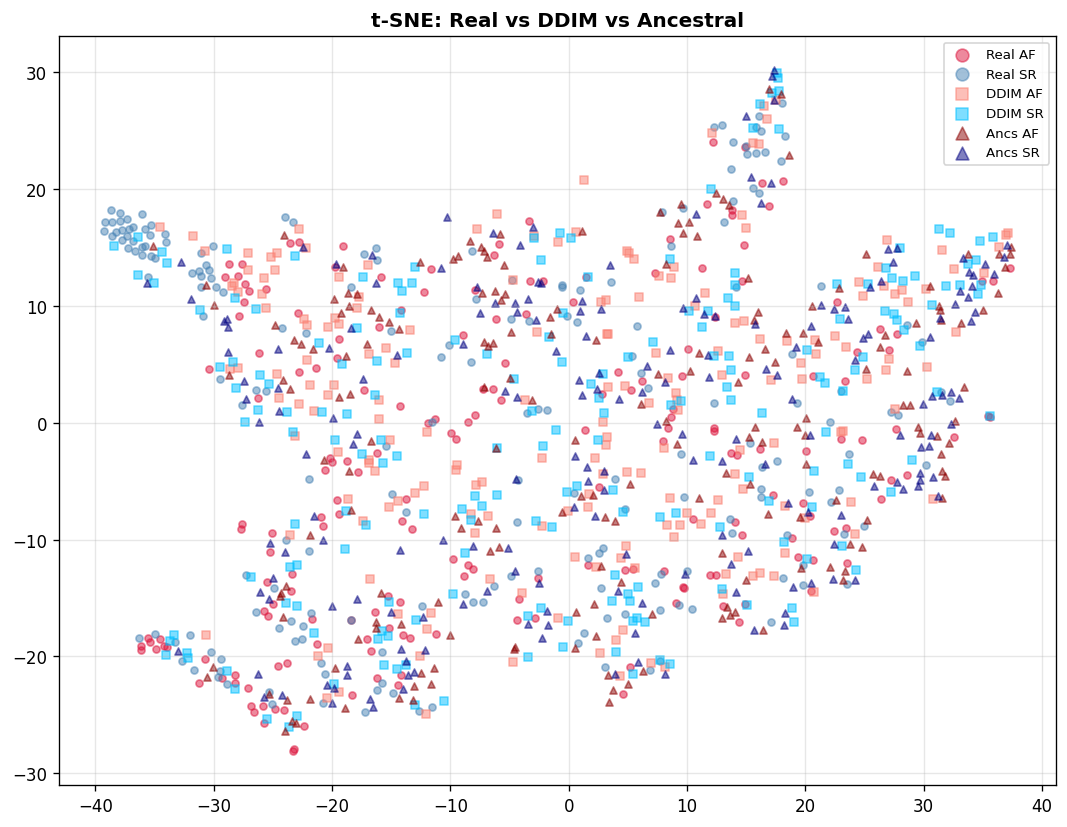

In [25]:
# ── Extração de Características e t-SNE (6-way) ─────────────────────────────
def feature_vec(signals):
    feats = []
    for sig in signals:
        try:
            peaks, _ = find_peaks(sig, distance=int(FS * 0.3), height=0.1)
            hr_v  = [FS * 60 / d for d in np.diff(peaks) if 30 < FS * 60 / d < 200]
            hr_m  = np.mean(hr_v) if hr_v else 75.0
            hr_s  = np.std(hr_v)  if len(hr_v) > 1 else 0.0
        except Exception:
            hr_m, hr_s = 75.0, 0.0

        freq, pxx = welch(sig, fs=FS, nperseg=256)
        p_lo = np.trapezoid(pxx[(freq >= 0) & (freq < 4)], freq[(freq >= 0) & (freq < 4)])
        p_hi = np.trapezoid(pxx[(freq >= 4) & (freq < 8)], freq[(freq >= 4) & (freq < 8)])
        feats.append([hr_m, hr_s, p_lo, p_hi, np.sqrt(np.mean(sig ** 2))])
    return np.array(feats)


# 1. Definir número de amostras e extrair características para os 6 grupos
N_TSNE = min(200, len(eval_real['AF']), len(eval_real['SR']))

feats = {
    'real_AF': feature_vec(eval_real['AF'][:N_TSNE]),
    'real_SR': feature_vec(eval_real['SR'][:N_TSNE]),
    'ddim_AF': feature_vec(eval_synth['ddim']['AF'][:N_TSNE]),
    'ddim_SR': feature_vec(eval_synth['ddim']['SR'][:N_TSNE]),
    'ancs_AF': feature_vec(eval_synth['ancs']['AF'][:N_TSNE]),
    'ancs_SR': feature_vec(eval_synth['ancs']['SR'][:N_TSNE]),
}

# 2. Distância de Wasserstein para DDIM e Ancestral
feat_names = ['HR_mean', 'HR_std', 'Power_0-4Hz', 'Power_4-8Hz', 'RMS']
print("Wasserstein distance (Real vs Synthetic):")
for samp, label in [('ddim', 'DDIM-100'), ('ancs', 'Ancestral')]:
    print(f"\n  Sampler: {label}")
    print(f"  {'Feature':<15}  {'AF':>10}  {'SR':>10}")
    print("  " + "─" * 38)
    for i, fn in enumerate(feat_names):
        wa = wasserstein_distance(feats['real_AF'][:, i], feats[f'{samp}_AF'][:, i])
        ws = wasserstein_distance(feats['real_SR'][:, i], feats[f'{samp}_SR'][:, i])
        print(f"    {fn:<13}  {wa:>10.4f}  {ws:>10.4f}")

# 3. Preparação dos dados e Normalização (6-way)
feat_keys = ['real_AF', 'real_SR', 'ddim_AF', 'ddim_SR', 'ancs_AF', 'ancs_SR']
all_f6 = np.concatenate([feats[k] for k in feat_keys])
all_l6 = (['Real AF'] * N_TSNE + ['Real SR'] * N_TSNE +
          ['DDIM AF'] * N_TSNE + ['DDIM SR'] * N_TSNE +
          ['Ancs AF'] * N_TSNE + ['Ancs SR'] * N_TSNE)

sc6 = StandardScaler().fit_transform(all_f6)

# 4. Cálculo do t-SNE
print("\nComputing t-SNE (6-way)...")
emb6 = TSNE(n_components=2, perplexity=40, random_state=SEED, n_iter=1000).fit_transform(sc6)

# 5. Visualização
cmap6 = {
    'Real AF': ('crimson', 'o'),    'Real SR': ('steelblue', 'o'),
    'DDIM AF': ('salmon', 's'),     'DDIM SR': ('deepskyblue', 's'),
    'Ancs AF': ('darkred', '^'),    'Ancs SR': ('navy', '^')
}

fig, ax = plt.subplots(figsize=(9, 7))
for lbl, (col, mrk) in cmap6.items():
    mask = [i for i, l in enumerate(all_l6) if l == lbl]
    ax.scatter(emb6[mask, 0], emb6[mask, 1], c=col, marker=mrk, alpha=0.5, s=18, label=lbl)

ax.set_title('t-SNE: Real vs DDIM vs Ancestral', fontweight='bold')
ax.legend(markerscale=1.8, fontsize=8, loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(WORK_DIR / 'fig_tsne.png', dpi=150)
plt.show()

In [26]:
# ── Parâmetros DTW ───────────────────────────────────────────────────────────
DOWN_FACTOR = 5     # Downsampling das janelas de sinal
DTW_BAND    = 25    # Banda de Sakoe-Chiba (em amostras)
N_DTW       = 30    # Amostras aleatórias por classe


def dtw_distance(a, b, band):
    """DTW com banda de Sakoe-Chiba usando custo absoluto |a_i - b_j|."""
    n, m = len(a), len(b)
    D = np.full((n + 1, m + 1), np.inf)
    D[0, 0] = 0.0
    for i in range(1, n + 1):
        j_lo = max(1, i - band)
        j_hi = min(m, i + band)
        for j in range(j_lo, j_hi + 1):
            cost = abs(a[i - 1] - b[j - 1])
            D[i, j] = cost + min(D[i - 1, j], D[i, j - 1], D[i - 1, j - 1])
    return D[n, m]


def dtw_nn_summary(real_sigs, synth_sigs, n=N_DTW, down=DOWN_FACTOR, band=DTW_BAND, seed=SEED):
    """Calcula a matriz N x N de distâncias DTW para extrair:
    - Fidelidade: menor distância de cada sinal sintético a um sinal real.
    - Cobertura:  menor distância de cada sinal real a um sinal sintético.
    """
    rng = np.random.RandomState(seed)
    idx_r = rng.choice(len(real_sigs),  min(n, len(real_sigs)),  replace=False)
    idx_s = rng.choice(len(synth_sigs), min(n, len(synth_sigs)), replace=False)
    
    R = [real_sigs[i][::down]  for i in idx_r]
    S = [synth_sigs[i][::down] for i in idx_s]

    D = np.zeros((len(S), len(R)))
    for i, s in enumerate(S):
        for j, r in enumerate(R):
            D[i, j] = dtw_distance(s, r, band)

    fidelity = float(D.min(axis=1).mean())
    coverage = float(D.min(axis=0).mean())
    return fidelity, coverage


# ── Execução e Apresentação de Resultados ────────────────────────────────────
print(f"DTW nearest-neighbour (N={N_DTW}/classe, downsample x{DOWN_FACTOR}, banda={DTW_BAND}):\n")

for samp, label in [('ddim', 'DDIM-100'), ('ancs', 'Ancestral')]:
    print(f"  {label}:")
    print(f"  {'Classe':<8}  {'Fidelidade':>12}  {'Cobertura':>12}")
    print("  " + "─" * 36)
    
    for rh in ['AF', 'SR']:
        fid, cov = dtw_nn_summary(eval_real[rh], eval_synth[samp][rh])
        print(f"  {rh:<8}  {fid:>12.3f}  {cov:>12.3f}")
    print()

print("(menor = mais parecido; fidelidade baixa e cobertura baixa juntas são o ideal)")

DTW nearest-neighbour (N=30/classe, downsample x5, banda=25):

  DDIM-100:
  Classe      Fidelidade     Cobertura
  ────────────────────────────────────
  AF              35.642        39.401
  SR              35.221        34.038

  Ancestral:
  Classe      Fidelidade     Cobertura
  ────────────────────────────────────
  AF              33.957        35.360
  SR              34.187        34.059

(menor = mais parecido; fidelidade baixa e cobertura baixa juntas são o ideal)


In [27]:
def dtw_nn_baseline(
    real_sigs, n=N_DTW, down=DOWN_FACTOR, band=DTW_BAND, seed=SEED
):
    """Calcula a baseline Real vs Real dividindo o dataset real em dois grupos disjuntos.

    Isto evita comparar um sinal consigo mesmo (distância 0).
    """
    rng = np.random.RandomState(seed)
    n_total = len(real_sigs)

    # Precisamos de 2 * n sinais reais únicos para fazer 2 grupos de tamanho n
    k = min(n, n_total // 2)
    indices = rng.choice(n_total, 2 * k, replace=False)

    idx_a = indices[:k]
    idx_b = indices[k:]

    real_A = [real_sigs[i] for i in idx_a]
    real_B = [real_sigs[i] for i in idx_b]

    # Reutiliza a função dtw_nn_summary entre os dois grupos reais
    fid_base, cov_base = dtw_nn_summary(
        real_A, real_B, n=k, down=down, band=band, seed=seed
    )

    # A média entre fidelidade e cobertura é o valor de referência
    return (fid_base + cov_base) / 2


# 1. Cálculos da Baseline (Real vs Real) - calculado uma vez por classe
base_af = dtw_nn_baseline(eval_real["AF"])
base_sr = dtw_nn_baseline(eval_real["SR"])

print(
    f"DTW nearest-neighbour (N={N_DTW}/classe, downsample x{DOWN_FACTOR},"
    f" banda={DTW_BAND}):\n"
)

# 2. Iteração pelos Samplers (DDIM-100 e Ancestral)
for samp, label in [('ddim', 'DDIM-100'), ('ancs', 'Ancestral')]:
    print(f"  {label}:")
    print(
        f"  {'Classe':<8}  {'Fidelidade':>12}  {'Cobertura':>12}"
        f"  {'Baseline (Real vs Real)':>23}"
    )
    print("  " + "─" * 58)
    
    for rh, base_val in [('AF', base_af), ('SR', base_sr)]:
        fid, cov = dtw_nn_summary(eval_real[rh], eval_synth[samp][rh])
        print(f"  {rh:<8}  {fid:>12.3f}  {cov:>12.3f}  {base_val:>23.3f}")
    print()

print("(quanto mais próximo a Fidelidade e Cobertura estiverem da Baseline Real vs Real, melhor)")

DTW nearest-neighbour (N=30/classe, downsample x5, banda=25):

  DDIM-100:
  Classe      Fidelidade     Cobertura  Baseline (Real vs Real)
  ──────────────────────────────────────────────────────────
  AF              35.642        39.401                   32.094
  SR              35.221        34.038                   30.851

  Ancestral:
  Classe      Fidelidade     Cobertura  Baseline (Real vs Real)
  ──────────────────────────────────────────────────────────
  AF              33.957        35.360                   32.094
  SR              34.187        34.059                   30.851

(quanto mais próximo a Fidelidade e Cobertura estiverem da Baseline Real vs Real, melhor)


### §10b — Nearest-Neighbour PRD & Pearson: DDIM vs Ancestral

In [28]:
def nn_prd_pearson(synth_sigs,real_sigs,n=200,seed=SEED):
    rng_=np.random.default_rng(seed); n=min(n,len(synth_sigs),len(real_sigs))
    syn=synth_sigs[rng_.choice(len(synth_sigs),n,replace=False)]
    rl=real_sigs[rng_.choice(len(real_sigs),n,replace=False)]
    prd_sr,pear_sr=[],[]
    for s in syn:
        dists=np.mean((rl-s)**2,axis=1); nn=rl[np.argmin(dists)]
        prd_sr.append(np.sqrt(np.sum((s-nn)**2)/(np.sum(nn**2)+1e-10))*100)
        pear_sr.append(pearsonr(s,nn)[0])
    prd_rr,pear_rr=[],[]
    for i in range(n):
        j=rng_.integers(0,n)
        while j==i: j=rng_.integers(0,n)
        r1,r2=rl[i],rl[j]
        prd_rr.append(np.sqrt(np.sum((r1-r2)**2)/(np.sum(r2**2)+1e-10))*100)
        pear_rr.append(pearsonr(r1,r2)[0])
    return {'prd_syn':(np.mean(prd_sr),np.std(prd_sr)),'prd_rr':(np.mean(prd_rr),np.std(prd_rr)),
            'pear_syn':(np.mean(pear_sr),np.std(pear_sr)),'pear_rr':(np.mean(pear_rr),np.std(pear_rr))}

print("Nearest-Neighbour PRD & Pearson (n=200 per class)")
print(f"  {'':20}  {'PRD synth→real':>18}  {'PRD real→real':>16}  {'Pearson synth':>15}  {'Pearson real':>14}")
print("  "+"─"*86)
nn_results={}
for samp,label in [('ddim','DDIM-100'),('ancs','Ancestral')]:
    for rh in ['AF','SR']:
        m=nn_prd_pearson(eval_synth[samp][rh],eval_real[rh])
        nn_results[f'{samp}_{rh}']=m
        print(f"  {label+' '+rh:<20}  {m['prd_syn'][0]:.2f}±{m['prd_syn'][1]:.2f}%  "
              f"{m['prd_rr'][0]:>10.2f}±{m['prd_rr'][1]:.2f}%  "
              f"{m['pear_syn'][0]:>11.4f}±{m['pear_syn'][1]:.4f}  "
              f"{m['pear_rr'][0]:>10.4f}±{m['pear_rr'][1]:.4f}")


Nearest-Neighbour PRD & Pearson (n=200 per class)
                            PRD synth→real     PRD real→real    Pearson synth    Pearson real
  ──────────────────────────────────────────────────────────────────────────────────────
  DDIM-100 AF           113.19±30.46%      139.51±28.84%       0.3816±0.1565     -0.0131±0.1744
  DDIM-100 SR           108.48±29.72%      149.31±39.84%       0.3771±0.1844      0.0067±0.1774
  Ancestral AF          108.53±34.12%      139.51±28.84%       0.3947±0.1801     -0.0131±0.1744
  Ancestral SR          110.14±30.43%      149.31±39.84%       0.3796±0.2042      0.0067±0.1774


In [ ]:
# ── §10b-v2 — Paired PRD/Pearson (conditioning-vector-paired, both samplers) ──
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler as _SS

N_PAIRED = 200

def _prd(real, synth):
    return 100.0*np.sqrt(np.sum((real-synth)**2)/(np.sum(real**2)+1e-10))

print('§10b-v2 — Paired PRD/Pearson (conditioning-vector-paired)')
print(f'N = {N_PAIRED} pares por classe, ambos os samplers\n')

paired_res = {}
for rh in ['AF','SR']:
    mask = df_test['rhythm']==rh
    n_use = min(N_PAIRED, mask.sum())
    rng_p = np.random.default_rng(SEED)
    idx_sel = rng_p.choice(np.where(mask)[0], n_use, replace=False)

    X_real_p = df_test['signals'][idx_sel].astype(np.float32)
    ibi_m_p, ibi_s_p, rmssd_p = df_test['ibi_mean'][idx_sel], df_test['ibi_std'][idx_sel], df_test['rmssd'][idx_sel]
    n_valid = len(X_real_p)
    if n_valid < 10:
        print(f'{rh}: menos de 10 sinais — a saltar'); continue

    nm,ns_v,nr = norm_ibi(ibi_m_p, ibi_s_p, rmssd_p)
    cond_t = torch.tensor(build_cond(nm,ns_v,nr,np.full(n_valid,rh)),dtype=torch.float32).to(DEVICE)

    cond_raw = np.stack([ibi_m_p,ibi_s_p,rmssd_p],axis=1)
    D_cond = pairwise_distances(_SS().fit_transform(cond_raw))
    np.fill_diagonal(D_cond, np.inf)
    nn_idx = D_cond.argmin(axis=1)
    prds_b,pccs_b = [],[]
    for i in range(n_valid):
        j=nn_idx[i]
        prds_b.append(_prd(X_real_p[i],X_real_p[j]))
        r=np.corrcoef(X_real_p[i],X_real_p[j])[0,1]
        if not np.isnan(r): pccs_b.append(r)

    paired_res[rh]={}
    for samp_key,label,gen in [('ddim','DDIM-100', lambda c: ddim_sample(ema_model,c,N_DDIM,BEST_GS)),
                                 ('ancs','Ancestral', lambda c: ancestral_sample(ema_model,c,BEST_GS))]:
        chunks=[]
        for i in range(0,len(cond_t),64):
            chunks.append(gen(cond_t[i:i+64]).cpu().numpy().squeeze(1))
        X_synth_p = np.concatenate(chunks)
        prds_p,pccs_p=[],[]
        for i in range(n_valid):
            prds_p.append(_prd(X_real_p[i],X_synth_p[i]))
            r=np.corrcoef(X_real_p[i],X_synth_p[i])[0,1]
            if not np.isnan(r): pccs_p.append(r)
        paired_res[rh][samp_key]=dict(
            prd_p=(np.mean(prds_p),np.std(prds_p)), pcc_p=(np.mean(pccs_p),np.std(pccs_p)),
            prd_b=(np.mean(prds_b),np.std(prds_b)), pcc_b=(np.mean(pccs_b),np.std(pccs_b)))
        torch.cuda.empty_cache()
        r_=paired_res[rh][samp_key]
        print(f'  {rh} {label}: PRD paired={r_["prd_p"][0]:.2f}%  baseline={r_["prd_b"][0]:.2f}%  '
              f'overhead={r_["prd_p"][0]-r_["prd_b"][0]:+.2f}%   '
              f'PCC paired={r_["pcc_p"][0]:.4f}  baseline={r_["pcc_b"][0]:.4f}  gap={r_["pcc_p"][0]-r_["pcc_b"][0]:+.4f}')

print(f'\n{"="*95}\n  §10b-v2 — Paired PRD/Pearson — resultados\n{"="*95}')
print(f"  {'':22}  {'PRD paired':>12}  {'PRD baseline':>13}  {'PCC paired':>11}  {'PCC baseline':>13}")
for rh in ['AF','SR']:
    if rh not in paired_res: continue
    for samp_key,label in [('ddim','DDIM'),('ancs','Ancs')]:
        r_=paired_res[rh][samp_key]
        print(f"  {rh+' '+label:<22}  {r_['prd_p'][0]:>9.2f}%  {r_['prd_b'][0]:>10.2f}%  "
              f"{r_['pcc_p'][0]:>11.4f}  {r_['pcc_b'][0]:>13.4f}")

### §10c — Conditioning Fidelity (NN and paired, both samplers)

In [32]:
print("BEST_GS =", BEST_GS)
print("type(BEST_GS) =", type(BEST_GS))

BEST_GS = 1.5
type(BEST_GS) = <class 'float'>


In [ ]:
# ── §10c (NN) — Conditioning Fidelity: HR MAE and IBI_std Ratio ─────────────
from scipy.signal import find_peaks as _find_peaks

def _extract_hr_ibi(signals, fs=FS):
    hrs, ibi_stds = [], []
    for sig in signals:
        try:
            peaks,_=_find_peaks(sig,distance=int(fs*0.3),height=0.05)
            ibi=np.diff(peaks)/fs; ibi=ibi[(ibi>=IBI_MIN)&(ibi<=IBI_MAX)]
            if len(ibi)>=2:
                hrs.append(60.0/ibi.mean()); ibi_stds.append(float(ibi.std()))
        except: pass
    return np.array(hrs), np.array(ibi_stds)

print('§10c (NN) — Conditioning Fidelity: HR MAE / IBI_std ratio\n')
cond_res={}
for samp,label in [('ddim','DDIM-100'),('ancs','Ancestral')]:
    cond_res[samp]={}
    for rh in ['AF','SR']:
        mask=df_test['rhythm']==rh
        n_use=min(N_EVAL,mask.sum())
        rng_c=np.random.default_rng(SEED)
        idx_c=rng_c.choice(np.where(mask)[0],n_use,replace=False)
        hr_target=60.0/df_test['ibi_mean'][idx_c]
        hrs_synth,ibi_stds_synth=_extract_hr_ibi(eval_synth[samp][rh])
        hrs_real, ibi_stds_real =_extract_hr_ibi(eval_real[rh])
        n_mae=min(len(hrs_synth),len(hr_target))
        mae_hr=float(np.mean(np.abs(hrs_synth[:n_mae]-hr_target[:n_mae])))
        ibi_ratio=(ibi_stds_synth.mean()/ibi_stds_real.mean()
                   if len(ibi_stds_real)>0 and ibi_stds_real.mean()>0 else float('nan'))
        cond_res[samp][rh]=dict(hr_target=hr_target.mean(),
                                 hr_synth=hrs_synth.mean() if len(hrs_synth) else float('nan'),
                                 mae_hr=mae_hr, ibi_ratio=ibi_ratio)

print('='*72+'\n  §10c (NN) — Conditioning Fidelity — Zenodo v2 DDPM\n'+'='*72)
print(f"  {'':22}  {'HR target':>10}  {'HR synth':>10}  {'MAE HR':>9}  {'IBI ratio':>10}")
for samp,label in [('ddim','DDIM-100'),('ancs','Ancestral')]:
    for rh in ['AF','SR']:
        r=cond_res[samp][rh]
        print(f"  {label+' '+rh:<22}  {r['hr_target']:>10.2f}  {r['hr_synth']:>10.2f}  "
              f"{r['mae_hr']:>8.3f}  {r['ibi_ratio']:>10.3f}")

In [ ]:
def conditioning_fidelity(sampler_fn, n_steps=None, n=200, eta=0.0, rh='AF'):
    mask = te_af if rh=='AF' else te_sr
    n = min(n, mask.sum())
    idx = np.random.choice(mask.sum(), n, replace=False)
    d = {k: v[mask] for k,v in df_test.items() if hasattr(v,'__len__') and len(v)==len(mask)}
    tgt_ibi_m=d['ibi_mean'][idx]; tgt_ibi_s=d['ibi_std'][idx]; tgt_rmssd=d['rmssd'][idx]
    tgt_hr=60./tgt_ibi_m
    nm,ns_v,nr=norm_ibi(tgt_ibi_m,tgt_ibi_s,tgt_rmssd)
    cond=torch.tensor(build_cond(nm,ns_v,nr,np.full(len(nm),rh)),dtype=torch.float32).to(DEVICE)
    syn=[]
    for i in range(0,len(cond),32):
        batch_cond=cond[i:i+32]
        if sampler_fn is ddim_sample:
            batch_syn=sampler_fn(ema_model,batch_cond,n_steps=N_DDIM,cfg_scale=BEST_GS,eta=eta)
        else:
            batch_syn=sampler_fn(ema_model,batch_cond,cfg_scale=BEST_GS)
        syn.append(batch_syn.cpu().numpy().squeeze(1))
    syn=np.concatenate(syn)
    gen_hr,gen_ibi_s,valid=[],[],[]
    for sig in syn:
        peaks,_=find_peaks(sig,distance=int(FS*0.35))
        if len(peaks)>=3:
            ibi=np.diff(peaks)/FS; ibi=ibi[(ibi>=IBI_MIN)&(ibi<=IBI_MAX)]
            if len(ibi)>=2:
                hr=60./np.mean(ibi)
                if 30<hr<200: gen_hr.append(hr); gen_ibi_s.append(np.std(ibi)); valid.append(True); continue
        gen_hr.append(np.nan); gen_ibi_s.append(np.nan); valid.append(False)
    gen_hr=np.array(gen_hr); gen_ibi_s=np.array(gen_ibi_s); valid=np.array(valid)
    if valid.sum()>1:
        th=tgt_hr[:len(gen_hr)][valid]; gh=gen_hr[valid]
        ts=tgt_ibi_s[:len(gen_ibi_s)][valid]; gs_v=gen_ibi_s[valid]
        mae_hr=float(np.mean(np.abs(gh-th))); ibi_ratio=float(np.mean(gs_v)/(np.mean(ts)+1e-8))
        p_hr,_=pearsonr(gh,th) if len(gh)>2 else (np.nan,None)
        p_ibi,_=pearsonr(gs_v,ts) if len(gs_v)>2 else (np.nan,None)
    else: mae_hr=ibi_ratio=p_hr=p_ibi=np.nan
    return {'mae_hr':mae_hr,'ibi_std_ratio':ibi_ratio,'peak_rate':valid.mean()*100,
            'pearson_hr':p_hr,'pearson_ibi':p_ibi,'n_valid':valid.sum()}

print("Paired conditioning fidelity (AF + SR)...")
fid_results={}
for rh in ['AF','SR']:
    fid_results[rh]={}
    for samp,label,fn in [('ddim','DDIM-100',ddim_sample),('ancs','Ancestral',ancestral_sample)]:
        fid=conditioning_fidelity(fn,n=200,rh=rh); fid_results[rh][samp]=fid
        print(f"\n  {rh} — {label}:  n_valid={fid['n_valid']}")
        print(f"    Peak detection rate: {fid['peak_rate']:.1f}%")
        print(f"    MAE HR (bpm)       : {fid['mae_hr']:.3f}")
        print(f"    IBI_std ratio      : {fid['ibi_std_ratio']:.3f}  (1.0=perfect)")
        print(f"    Pearson HR         : {fid['pearson_hr']:.4f}")
        print(f"    Pearson IBI_std    : {fid['pearson_ibi']:.4f}")

## §11 — Part A: In-Domain Functional Validation (DDIM vs Ancestral)

In [36]:
# ── Classifier architectures (same as CFM notebook) ─────────────────────────
class Clf1D(nn.Module):
    def __init__(self):
        super().__init__()
        self.net=nn.Sequential(
            nn.Conv1d(1,32,15,stride=2,padding=7),nn.BatchNorm1d(32),nn.ReLU(),
            nn.Conv1d(32,64,9,stride=2,padding=4),nn.BatchNorm1d(64),nn.ReLU(),
            nn.Conv1d(64,128,7,stride=2,padding=3),nn.BatchNorm1d(128),nn.ReLU(),
            nn.Conv1d(128,256,5,stride=4,padding=2),nn.BatchNorm1d(256),nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),nn.Flatten(),nn.Linear(256,64),nn.ReLU(),nn.Dropout(0.3),nn.Linear(64,1))
    def forward(self,x): return self.net(x).squeeze(1)

class ClfUNetGAN(nn.Module):
    def __init__(self):
        super().__init__()
        filt=[1,4,8,16,32,64,128]; layers=[]
        for i in range(len(filt)-1): layers+=[nn.Conv1d(filt[i],filt[i+1],kernel_size=3,padding=1),nn.LeakyReLU(0.15)]
        layers+=[nn.AdaptiveAvgPool1d(1),nn.Flatten()]; self.features=nn.Sequential(*layers); self.classifier=nn.Linear(128,2)
    def forward(self,x): return self.classifier(self.features(x))

def find_best_thr(y_true,probs):
    thrs=np.linspace(0.01,0.99,99); f1s=[f1_score(y_true,(probs>t).astype(int),zero_division=0) for t in thrs]; return float(thrs[np.argmax(f1s)])

def train_clf1d(Xtr,ytr,Xvl,yvl,epochs=30,lr=1e-3,batch=128):
    clf=Clf1D().to(DEVICE); pw=torch.tensor([len(ytr[ytr==0])/(len(ytr[ytr==1])+1e-8)],dtype=torch.float32).to(DEVICE)
    crit=nn.BCEWithLogitsLoss(pos_weight=pw); opt=torch.optim.Adam(clf.parameters(),lr=lr,weight_decay=1e-4)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs)
    Xt=torch.tensor(Xtr[:,None,:],dtype=torch.float32); yt=torch.tensor(ytr,dtype=torch.float32)
    Xv=torch.tensor(Xvl[:,None,:],dtype=torch.float32).to(DEVICE)
    dl=DataLoader(list(zip(Xt,yt)),batch_size=batch,shuffle=True); best_auc,best_st=0.,None
    for ep in range(epochs):
        clf.train()
        for xb,yb in dl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad(); crit(clf(xb),yb).backward(); opt.step()
        sch.step(); clf.eval()
        with torch.no_grad(): lg=clf(Xv).cpu().numpy()
        auc=roc_auc_score(yvl,lg)
        if auc>best_auc: best_auc=auc; best_st={k:v.clone() for k,v in clf.state_dict().items()}
    clf.load_state_dict(best_st); clf.eval()
    with torch.no_grad(): vp=torch.sigmoid(clf(Xv)).cpu().numpy()
    return clf, find_best_thr(yvl,vp)

def eval_clf1d(clf,Xte,yte,thr=0.5):
    clf.eval()
    with torch.no_grad(): lg=clf(torch.tensor(Xte[:,None,:],dtype=torch.float32).to(DEVICE)).cpu().numpy()
    probs=1/(1+np.exp(-lg)); preds=(probs>thr).astype(int)
    tn,fp,fn,tp=confusion_matrix(yte,preds,labels=[0,1]).ravel()
    return {'auroc':roc_auc_score(yte,probs),'f1':f1_score(yte,preds,zero_division=0),
            'precision':precision_score(yte,preds,zero_division=0),'recall':float(tp/(tp+fn+1e-9)),
            'specificity':float(tn/(tn+fp+1e-9)),'accuracy':accuracy_score(yte,preds)}

def train_unetgan(Xtr,ytr,Xvl,yvl,epochs=30,lr=1e-3,batch=128):
    clf=ClfUNetGAN().to(DEVICE); opt=torch.optim.Adam(clf.parameters(),lr=lr)
    sch=torch.optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs); crit=nn.CrossEntropyLoss()
    Xt=torch.tensor(Xtr[:,None,:],dtype=torch.float32); yt=torch.tensor(ytr,dtype=torch.long)
    Xv=torch.tensor(Xvl[:,None,:],dtype=torch.float32)
    dl=DataLoader(list(zip(Xt,yt)),batch_size=batch,shuffle=True); best_auc,best_st=0.,None
    for ep in range(epochs):
        clf.train()
        for xb,yb in dl:
            xb,yb=xb.to(DEVICE),yb.to(DEVICE); opt.zero_grad(); crit(clf(xb),yb).backward(); opt.step()
        sch.step(); clf.eval()
        with torch.no_grad(): lgs=clf(Xv.to(DEVICE)).cpu().numpy()
        probs=torch.softmax(torch.tensor(lgs),dim=1).numpy()[:,1]; auc=roc_auc_score(yvl,probs)
        if auc>best_auc: best_auc=auc; best_st={k:v.clone() for k,v in clf.state_dict().items()}
    clf.load_state_dict(best_st); clf.eval()
    with torch.no_grad(): lgs_v=clf(Xv.to(DEVICE)).cpu().numpy()
    probs_v=torch.softmax(torch.tensor(lgs_v),dim=1).numpy()[:,1]
    return clf, find_best_thr(yvl,probs_v)

def eval_unetgan(clf,Xte,yte,thr=0.5):
    clf.eval()
    with torch.no_grad(): lgs=clf(torch.tensor(Xte[:,None,:],dtype=torch.float32).to(DEVICE)).cpu().numpy()
    probs=torch.softmax(torch.tensor(lgs),dim=1).numpy()[:,1]; preds=(probs>thr).astype(int)
    tn,fp,fn,tp=confusion_matrix(yte,preds,labels=[0,1]).ravel()
    return {'accuracy':accuracy_score(yte,preds),'auroc':roc_auc_score(yte,probs),
            'precision':precision_score(yte,preds,zero_division=0),'recall':float(tp/(tp+fn+1e-9)),
            'sensitivity':float(tp/(tp+fn+1e-9)),'specificity':float(tn/(tn+fp+1e-9)),
            'f1':f1_score(yte,preds,zero_division=0)}

def print_table(res,title):
    print(); print("="*112); print(f"  {title}"); print("="*112)
    print(f"  {'Dataset':<46}  {'Accuracy':>10}  {'AUROC':>12}  {'Precision':>10}  {'Recall':>9}  {'Specif.':>9}  {'F1':>9}")
    print("  "+"─"*104)
    for ds,m in res.items():
        print(f"  {ds:<46}  {m['accuracy'][0]:.4f}±{m['accuracy'][1]:.3f}  {m['auroc'][0]:.4f}±{m['auroc'][1]:.3f}  {m['precision'][0]:.4f}±{m['precision'][1]:.3f}  {m['recall'][0]:.4f}±{m['recall'][1]:.3f}  {m['specificity'][0]:.4f}±{m['specificity'][1]:.3f}  {m['f1'][0]:.4f}±{m['f1'][1]:.3f}")
    print("="*112)

print("Classifiers and helpers defined.")


Classifiers and helpers defined.


In [37]:
# ── Arrays ───────────────────────────────────────────────────────────────────
tr_af_mask = (df_train['rhythm'] == 'AF')
tr_sr_mask = (df_train['rhythm'] == 'SR')
X_tr_r = df_train['signals'].astype(np.float32)
y_tr_r = (df_train['rhythm'] == 'AF').astype(int)
X_vl   = df_val['signals'].astype(np.float32)
y_vl   = (df_val['rhythm'] == 'AF').astype(int)
X_te   = df_test['signals'].astype(np.float32)
y_te   = (df_test['rhythm'] == 'AF').astype(int)

n_af_tr = tr_af_mask.sum()
n_sr_tr = min(tr_sr_mask.sum(), n_af_tr)
idx1 = np.where(tr_af_mask)[0]
idx0 = np.where(tr_sr_mask)[0][:n_sr_tr]
X_tr = np.concatenate([X_tr_r[idx1], X_tr_r[idx0]])
y_tr = np.concatenate([np.ones(len(idx1)), np.zeros(n_sr_tr)]).astype(int)

# ── Generate training synthetic pools (both samplers) ────────────────────────
N_SYNTH = 1000#3200
synth_train = {'ddim': {}, 'ancs': {}}

print("Generating training synthetic pools (both samplers)...")
for rh in ['AF', 'SR']:
    mask = df_train['rhythm'] == rh
    n_av = mask.sum()
    idx_s = np.random.choice(n_av, min(N_SYNTH, n_av), replace=False)
    nm, ns_v, nr = norm_ibi(df_train['ibi_mean'][mask][idx_s],
                            df_train['ibi_std'][mask][idx_s],
                            df_train['rmssd'][mask][idx_s])
    cond = torch.tensor(build_cond(nm, ns_v, nr, np.full(len(idx_s), rh)), dtype=torch.float32).to(DEVICE)
    
    # DDIM
    out_d = []
    for i in range(0, len(cond), 64):
        out_d.append(ddim_sample(ema_model, cond[i:i+64], N_DDIM, BEST_GS).cpu().numpy().squeeze(1))
    synth_train['ddim'][rh] = np.concatenate(out_d)
    print(f"  DDIM {rh}: {synth_train['ddim'][rh].shape[0]}")
    
    # Ancestral
    out_a = []
    print(f"  Ancestral {rh} training pool...")
    for i in range(0, len(cond), 32):
        out_a.append(ancestral_sample(ema_model, cond[i:i+32], BEST_GS).cpu().numpy().squeeze(1))
    synth_train['ancs'][rh] = np.concatenate(out_a)
    print(f"  Ancestral {rh}: {synth_train['ancs'][rh].shape[0]}")

# ── Preparing Datasets for TRTR / TSTR / ClfB ─────────────────────────────────
# DDIM Datasets
n_syn_d = min(len(synth_train['ddim']['AF']), len(synth_train['ddim']['SR']))
X_syn_d = np.concatenate([synth_train['ddim']['AF'][:n_syn_d], synth_train['ddim']['SR'][:n_syn_d]])
y_syn_d = np.array([1]*n_syn_d + [0]*n_syn_d)
X_clb_d = np.concatenate([X_tr, X_syn_d])
y_clb_d = np.concatenate([y_tr, y_syn_d])

# Ancestral Datasets
n_syn_a = min(len(synth_train['ancs']['AF']), len(synth_train['ancs']['SR']))
X_syn_a = np.concatenate([synth_train['ancs']['AF'][:n_syn_a], synth_train['ancs']['SR'][:n_syn_a]])
y_syn_a = np.array([1]*n_syn_a + [0]*n_syn_a)
X_clb_a = np.concatenate([X_tr, X_syn_a])
y_clb_a = np.concatenate([y_tr, y_syn_a])

# Lista de condições a avaliar
eval_conditions = [
    ('TRTR', X_tr, y_tr),
    ('TSTR (DDIM)', X_syn_d, y_syn_d),
    ('ClfB (DDIM)', X_clb_d, y_clb_d),
    ('TSTR (Ancs)', X_syn_a, y_syn_a),
    ('ClfB (Ancs)', X_clb_a, y_clb_a),
]

# ── Execução da Avaliação (5 Seeds) ───────────────────────────────────────────
N_SEEDS = 5
results11a = {}

for cond_name, Xtr_c, ytr_c in eval_conditions:
    print(f"\n{cond_name}...")
    ml = {k: [] for k in ['auroc', 'f1', 'precision', 'recall', 'specificity', 'accuracy', 'threshold']}
    for s in range(N_SEEDS):
        torch.manual_seed(s)
        np.random.seed(s)
        clf, thr = train_clf1d(Xtr_c, ytr_c, X_vl, y_vl)
        m = eval_clf1d(clf, X_te, y_te, thr)
        
        # Correção do KeyError: atribui o threshold ao dicionário de métricas
        m['threshold'] = thr  
        
        for k in ml:
            ml[k].append(m[k])
        print(f"  seed {s}: AUROC={m['auroc']:.4f}  F1={m['f1']:.4f}  thr={thr:.2f}")
        
    results11a[cond_name] = {k: (float(np.mean(v)), float(np.std(v))) for k, v in ml.items()}
    r = results11a[cond_name]
    print(f"  → AUROC={r['auroc'][0]:.4f}±{r['auroc'][1]:.4f}  F1={r['f1'][0]:.4f}")

# ── Tabela de Resultados ──────────────────────────────────────────────────────
print()
print("╔═════════════════════════════════════════════════════════════════════════════╗")
print("║            DDPM — Clf1D Functional Evaluation (DDIM vs Ancestral)           ║")
print("╠═════════════════════════════════════════════════════════════════════════════╣")
print(f"║  {'Condition':<15}  {'AUROC':>15}  {'Precision':>15}  {'F1':>15}  ║")
print("║  " + "─" * 67 + "  ║")
for cond, m in results11a.items():
    print(f"║  {cond:<15}  {m['auroc'][0]:.4f}±{m['auroc'][1]:.4f}  "
          f"{m['precision'][0]:.4f}±{m['precision'][1]:.4f}  "
          f"{m['f1'][0]:.4f}±{m['f1'][1]:.4f}  ║")
print("╚═════════════════════════════════════════════════════════════════════════════╝")

Generating training synthetic pools (both samplers)...
  DDIM AF: 1000
  Ancestral AF training pool...
  Ancestral AF: 1000
  DDIM SR: 1000
  Ancestral SR training pool...
  Ancestral SR: 1000

TRTR...
  seed 0: AUROC=0.6889  F1=0.4205  thr=0.68
  seed 1: AUROC=0.7001  F1=0.4000  thr=0.58
  seed 2: AUROC=0.6899  F1=0.4281  thr=0.58
  seed 3: AUROC=0.7030  F1=0.4398  thr=0.55
  seed 4: AUROC=0.7241  F1=0.4408  thr=0.54
  → AUROC=0.7012±0.0127  F1=0.4259

TSTR (DDIM)...
  seed 0: AUROC=0.6931  F1=0.4033  thr=0.69
  seed 1: AUROC=0.7191  F1=0.4157  thr=0.70
  seed 2: AUROC=0.6834  F1=0.4411  thr=0.80
  seed 3: AUROC=0.6812  F1=0.4514  thr=0.65
  seed 4: AUROC=0.7012  F1=0.3922  thr=0.81
  → AUROC=0.6956±0.0138  F1=0.4208

ClfB (DDIM)...
  seed 0: AUROC=0.7336  F1=0.4362  thr=0.59
  seed 1: AUROC=0.6857  F1=0.4437  thr=0.55
  seed 2: AUROC=0.6882  F1=0.4261  thr=0.73
  seed 3: AUROC=0.7143  F1=0.4398  thr=0.53
  seed 4: AUROC=0.7056  F1=0.4606  thr=0.63
  → AUROC=0.7055±0.0176  F1=0.4413



In [40]:
# ── Baseline comparison (unconditioned, both samplers) ───────────────────────
null_t=torch.zeros(N_EVAL,RAW_COND_DIM,dtype=torch.float32).to(DEVICE)
base_synth={'ddim':{},'ancs':{}}
for rh in ['AF','SR']:
    out_d=[]
    for i in range(0,len(null_t),64): out_d.append(ddim_sample(ema_model,null_t[i:i+64],N_DDIM,cfg_scale=0.0).cpu().numpy().squeeze(1))
    base_synth['ddim'][rh]=np.concatenate(out_d)
    out_a=[]
    for i in range(0,len(null_t),32): out_a.append(ancestral_sample(ema_model,null_t[i:i+32],cfg_scale=0.0).cpu().numpy().squeeze(1))
    base_synth['ancs'][rh]=np.concatenate(out_a)

print("=== BASELINE vs CONDITIONED COMPARISON ===")
print(f"  {'Metric':<25}  {'DDIM-100 cond':>14}  {'DDIM uncond':>13}  {'Ancs cond':>11}  {'Ancs uncond':>12}")
print("  "+"─"*78)
for rh,metric in [('AF','LSD AF (0.5-8)'),('SR','LSD SR (0.5-8)')]:
    lc_d=lsd(eval_real[rh],eval_synth['ddim'][rh]); lu_d=lsd(eval_real[rh],base_synth['ddim'][rh])
    lc_a=lsd(eval_real[rh],eval_synth['ancs'][rh]); lu_a=lsd(eval_real[rh],base_synth['ancs'][rh])
    print(f"  {metric:<25}  {lc_d:>14.4f}  {lu_d:>13.4f}  {lc_a:>11.4f}  {lu_a:>12.4f}")

# ── Código original com o ajuste de acesso ao dicionário ───────────────────────
for samp, label, key_name in [('ddim', 'DDIM', 'TSTR (DDIM)'), ('ancs', 'Ancs', 'TSTR (Ancs)')]:
    X_base = np.concatenate([base_synth[samp]['AF'], base_synth[samp]['SR']])
    y_base = np.array([1]*N_EVAL + [0]*N_EVAL)
    
    torch.manual_seed(0)
    np.random.seed(0)
    
    clf_b, thr_b = train_clf1d(X_base, y_base, X_vl, y_vl)
    m_b = eval_clf1d(clf_b, X_te, y_te, thr_b)
    
    # Acesso corrigido utilizando a chave correta diretamente do dicionário:
    tstr_cond = results11a[key_name]['auroc'][0]   # TSTR conditioned
    
    print(f"  {'TSTR AUROC '+label:<25}  {tstr_cond:>14.4f}  {m_b['auroc']:>13.4f}  (gain: {tstr_cond-m_b['auroc']:+.4f})")

=== BASELINE vs CONDITIONED COMPARISON ===
  Metric                      DDIM-100 cond    DDIM uncond    Ancs cond   Ancs uncond
  ──────────────────────────────────────────────────────────────────────────────
  LSD AF (0.5-8)                     8.2512         8.9636       7.9837        8.5665
  LSD SR (0.5-8)                     8.8704         9.4706       8.5311        8.8933
  TSTR AUROC DDIM                    0.6956         0.4486  (gain: +0.2469)
  TSTR AUROC Ancs                    0.6394         0.4716  (gain: +0.1678)


In [45]:
# ── ClfUNetGAN DA1–DA5 — both samplers ───────────────────────────────────────
real_pool = eval_real
rng_a = np.random.default_rng(0)
N_UNIT=min(len(real_pool['AF']),len(real_pool['SR']),len(synth_train['ddim']['AF']),len(synth_train['ddim']['SR']))
N_H=N_UNIT//2; N_75=int(N_UNIT*1.5); N_25=N_UNIT//2
print(f"Balancing unit N_UNIT={N_UNIT}")

def samp(arr,n,rng=rng_a): return arr[rng.choice(len(arr),min(n,len(arr)),replace=False)]

results_DA={}
for samp_key,label in [('ddim','DDIM-100'),('ancs','Ancestral')]:
    sp=synth_train[samp_key]
    datasets={'DA1 — 50% synth AF + 50% real SR':          (np.vstack([samp(sp['AF'],N_UNIT),samp(real_pool['SR'],N_UNIT)]),np.array([1]*N_UNIT+[0]*N_UNIT)),
              'DA2 — 25% synth AF + 25% real AF + 50% SR': (np.vstack([samp(sp['AF'],N_H),samp(real_pool['AF'],N_H),samp(real_pool['SR'],N_UNIT)]),np.array([1]*N_H+[1]*N_H+[0]*N_UNIT)),
              'DA3 — 50% real AF + 50% synth SR':          (np.vstack([samp(real_pool['AF'],N_UNIT),samp(sp['SR'],N_UNIT)]),np.array([1]*N_UNIT+[0]*N_UNIT)),
              'DAref — 50% real AF + 50% real SR (base)':  (np.vstack([samp(real_pool['AF'],N_UNIT),samp(real_pool['SR'],N_UNIT)]),np.array([1]*N_UNIT+[0]*N_UNIT)),
              'DA5 — 75% real AF + 25% real SR (imbal.)':  (np.vstack([samp(real_pool['AF'],N_75),samp(real_pool['SR'],N_25)]),np.array([1]*N_75+[0]*N_25))}
    results_DA[samp_key]={}
    print(f"\nClfUNetGAN DA1-DA5 — {label}")
    for ds_n,(Xtr_d,ytr_d) in datasets.items():
        ml={k:[] for k in ['accuracy','auroc','precision','recall','sensitivity','specificity','f1']}
        for s in range(5):
            torch.manual_seed(s); np.random.seed(s)
            clf,thr=train_unetgan(Xtr_d,ytr_d,X_vl,y_vl); m=eval_unetgan(clf,X_te,y_te,thr)
            for k in ml: ml[k].append(m[k])
        results_DA[samp_key][ds_n]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml.items()}
    print_table(results_DA[samp_key],f'ClfUNetGAN DA1–DA5 — {label} — Zenodo v2 DDPM')


Balancing unit N_UNIT=300

ClfUNetGAN DA1-DA5 — DDIM-100

  ClfUNetGAN DA1–DA5 — DDIM-100 — Zenodo v2 DDPM
  Dataset                                           Accuracy         AUROC   Precision     Recall    Specif.         F1
  ────────────────────────────────────────────────────────────────────────────────────────────────────────
  DA1 — 50% synth AF + 50% real SR                0.3390±0.000  0.4452±0.004  0.3396±0.000  0.9856±0.001  0.0025±0.000  0.5051±0.000
  DA2 — 25% synth AF + 25% real AF + 50% SR       0.3406±0.001  0.4733±0.014  0.3409±0.001  0.9923±0.006  0.0014±0.001  0.5074±0.002
  DA3 — 50% real AF + 50% synth SR                0.3645±0.034  0.5092±0.020  0.3374±0.006  0.8958±0.145  0.0880±0.127  0.4878±0.031
  DAref — 50% real AF + 50% real SR (base)        0.3564±0.019  0.5299±0.022  0.3424±0.007  0.9572±0.065  0.0437±0.054  0.5040±0.015
  DA5 — 75% real AF + 25% real SR (imbal.)        0.3443±0.004  0.4810±0.026  0.3408±0.003  0.9809±0.038  0.0129±0.026  0.5058±0.008



## §12-14 — Cross-Domain FV (Parts B · C · D): MIMIC-AF · VitalDB · MIMIC-III-Ext
*Each external dataset: generate with DDIM + Ancestral → fidelity → ClfUNetGAN on two test sets*

In [46]:
def xdomain_generate(cond_np, label, batch_ddim=64, batch_ancs=32):
    """Generate synthetics with both samplers from external conditioning."""    
    cond_t=torch.tensor(cond_np,dtype=torch.float32).to(DEVICE)
    out_d=[]
    for i in range(0,len(cond_t),batch_ddim): out_d.append(ddim_sample(ema_model,cond_t[i:i+batch_ddim],N_DDIM,BEST_GS).cpu().numpy().squeeze(1))
    synth_d=np.concatenate(out_d); print(f"  DDIM {label}: {synth_d.shape}")
    out_a=[]
    print(f"  Ancestral {label} ({len(cond_t)} windows)...")
    for i in range(0,len(cond_t),batch_ancs): out_a.append(ancestral_sample(ema_model,cond_t[i:i+batch_ancs],BEST_GS).cpu().numpy().squeeze(1))
    synth_a=np.concatenate(out_a); print(f"  Ancs {label}: {synth_a.shape}")
    return synth_d,synth_a

def xdomain_fidelity(real_ext, synth_d, synth_a, ext_label, N_F=200):
    """LSD · Wasserstein · MMD · DTW · t-SNE for external domain (both samplers)."""    
    N_F=min(N_F,len(real_ext)); fe_r=feature_vec(real_ext[:N_F]); fe_d=feature_vec(synth_d[:N_F]); fe_a=feature_vec(synth_a[:N_F])
    print(f"\nFidelity — {ext_label}:")
    print(f"  {'Metric':<20}  {'DDIM':>12}  {'Ancestral':>12}  {'In-domain ref':>14}")
    lsd_ref=(lsd_results['ddim']['AF']+lsd_results['ddim']['SR'])/2
    lsd_d=lsd(real_ext[:N_F],synth_d[:N_F]); lsd_a=lsd(real_ext[:N_F],synth_a[:N_F])
    print(f"  {'LSD (0.5-8 Hz, dB)':<20}  {lsd_d:>12.4f}  {lsd_a:>12.4f}  {lsd_ref:>14.4f}")
    wd_d=[wasserstein_distance(fe_r[:,i],fe_d[:,i]) for i in range(5)]
    wd_a=[wasserstein_distance(fe_r[:,i],fe_a[:,i]) for i in range(5)]
    print(f"  {'Mean Wasserstein':<20}  {np.mean(wd_d):>12.4f}  {np.mean(wd_a):>12.4f}")
    mmd_d=mmd_rbf(fe_r,fe_d,n=N_F); mmd_a=mmd_rbf(fe_r,fe_a,n=N_F); mmd_xd=mmd_rbf(fe_r,feats['real_AF'],n=N_F)
    print(f"  {'MMD²':<20}  {mmd_d:>12.6f}  {mmd_a:>12.6f}  (domain gap={mmd_xd:.6f})")
    dtw_dm,dtw_ds=batch_dtw(real_ext,synth_d); dtw_am,dtw_as=batch_dtw(real_ext,synth_a)
    print(f"  {'DTW':<20}  {dtw_dm:>6.3f}±{dtw_ds:.3f}  {dtw_am:>6.3f}±{dtw_as:.3f}")
    return {'lsd_d':lsd_d,'lsd_a':lsd_a,'mmd_d':mmd_d,'mmd_a':mmd_a,'dtw_d':(dtw_dm,dtw_ds),'dtw_a':(dtw_am,dtw_as)}

def xdomain_clf(synth_d, synth_a, real_pool, X_vl, y_vl, X_te1, y_te1, X_te2, y_te2, datasets_fn, tag='B'):
    """ClfUNetGAN on DB/DC/DD datasets, two test sets, both samplers."""    
    results_z={'ddim':{},'ancs':{}}; results_x={'ddim':{},'ancs':{}}
    for samp_key,label,synth_ext in [('ddim','DDIM',synth_d),('ancs','Ancs',synth_a)]:
        datasets=datasets_fn(synth_ext,real_pool); print(f"\n  {label}:")
        for ds_n,(Xtr_d,ytr_d) in datasets.items():
            ml_z={k:[] for k in ['accuracy','auroc','precision','recall','sensitivity','specificity','f1']}
            ml_x={k:[] for k in ml_z}
            for s in range(5):
                torch.manual_seed(s); np.random.seed(s)
                clf,thr=train_unetgan(Xtr_d,ytr_d,X_vl,y_vl)
                mz=eval_unetgan(clf,X_te1,y_te1,thr); mx=eval_unetgan(clf,X_te2,y_te2,thr)
                for k in ml_z: ml_z[k].append(mz[k])
                for k in ml_x: ml_x[k].append(mx[k])
                print(f"    {ds_n[:20]} seed{s}: [Zen] AUROC={mz['auroc']:.4f}  [XDom] AUROC={mx['auroc']:.4f}")
            results_z[samp_key][ds_n]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_z.items()}
            results_x[samp_key][ds_n]={k:(float(np.mean(v)),float(np.std(v))) for k,v in ml_x.items()}
        print_table(results_z[samp_key],f'D{tag} [Test 1: Zenodo] — {label}')
        print_table(results_x[samp_key],f'D{tag} [Test 2: XDom] — {label}')
    return results_z,results_x

print("Cross-domain helpers defined.")


Cross-domain helpers defined.


In [51]:
import numpy as np

# ── 1. MMD RBF ────────────────────────────────────────────────────────────────
def mmd_rbf(X, Y, gamma=None, n=None):
    if n is not None:
        idx_x = np.random.choice(len(X), min(n, len(X)), replace=False)
        idx_y = np.random.choice(len(Y), min(n, len(Y)), replace=False)
        X, Y = X[idx_x], Y[idx_y]
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    def rbf_kernel(A, B):
        dist = np.sum(A**2, axis=1)[:, None] + np.sum(B**2, axis=1)[None, :] - 2 * np.dot(A, B.T)
        return np.exp(-gamma * np.maximum(dist, 0))
    K_XX = rbf_kernel(X, X); K_YY = rbf_kernel(Y, Y); K_XY = rbf_kernel(X, Y)
    return float(np.mean(K_XX) + np.mean(K_YY) - 2 * np.mean(K_XY))

# ── 2. Batch DTW (Função que faltava) ──────────────────────────────────────────
#def batch_dtw(real_sigs, synth_sigs, n_samples=50):
#    """Calcula a distância DTW média e desvio padrão entre pares de sinais."""
#    try:
#        from fastdtw import fastdtw
#        from scipy.spatial.distance import euclidean
#        dtw_fn = lambda x, y: fastdtw(x, y, dist=euclidean)[0]
#    except ImportError:
#        # Fallback usando scipy.spatial.distance.correlation ou matriz de distância simplificada
#        from scipy.spatial.distance import cdist
#        def dtw_fn(x, y):
#            D = cdist(x[:, None], y[:, None], metric='sqeuclidean')
#            return np.sqrt(D.min(axis=1).sum())
#
#    n = min(n_samples, len(real_sigs), len(synth_sigs))
#    idx_r = np.random.choice(len(real_sigs), n, replace=False)
#    idx_s = np.random.choice(len(synth_sigs), n, replace=False)
#    
#    distances = []
#    for r, s in zip(real_sigs[idx_r], synth_sigs[idx_s]):
#        try:
#            dist = dtw_fn(r, s)
#            distances.append(dist)
#        except Exception:
#            pass
#            
#    if len(distances) == 0:
#        return np.nan, np.nan
#    return float(np.mean(distances)), float(np.std(distances))

# ── 3. Atualizar a xdomain_fidelity ───────────────────────────────────────────
def xdomain_fidelity(real_ext, synth_d, synth_a, ext_label, N_F=200):
    N_F=min(N_F,len(real_ext)); fe_r=feature_vec(real_ext[:N_F]); fe_d=feature_vec(synth_d[:N_F]); fe_a=feature_vec(synth_a[:N_F])
    print(f"\nFidelity — {ext_label}:")
    print(f"  {'Metric':<20}  {'DDIM':>12}  {'Ancestral':>12}  {'In-domain ref':>14}")
    lsd_ref=(lsd_results['ddim']['AF']+lsd_results['ddim']['SR'])/2
    lsd_d=lsd(real_ext[:N_F],synth_d[:N_F]); lsd_a=lsd(real_ext[:N_F],synth_a[:N_F])
    print(f"  {'LSD (0.5-8 Hz, dB)':<20}  {lsd_d:>12.4f}  {lsd_a:>12.4f}  {lsd_ref:>14.4f}")
    wd_d=[wasserstein_distance(fe_r[:,i],fe_d[:,i]) for i in range(5)]
    wd_a=[wasserstein_distance(fe_r[:,i],fe_a[:,i]) for i in range(5)]
    print(f"  {'Mean Wasserstein':<20}  {np.mean(wd_d):>12.4f}  {np.mean(wd_a):>12.4f}")
    mmd_d=mmd_rbf(fe_r,fe_d,n=N_F); mmd_a=mmd_rbf(fe_r,fe_a,n=N_F); mmd_xd=mmd_rbf(fe_r,feats['real_AF'],n=N_F)
    print(f"  {'MMD²':<20}  {mmd_d:>12.6f}  {mmd_a:>12.6f}  (domain gap={mmd_xd:.6f})")
    fid_d,cov_d=dtw_nn_summary(real_ext[:N_F],synth_d[:N_F])
    fid_a,cov_a=dtw_nn_summary(real_ext[:N_F],synth_a[:N_F])
    print(f"  {'DTW fidelity':<20}  {fid_d:>12.3f}  {fid_a:>12.3f}")
    print(f"  {'DTW coverage':<20}  {cov_d:>12.3f}  {cov_a:>12.3f}")
    return {'lsd_d':lsd_d,'lsd_a':lsd_a,'mmd_d':mmd_d,'mmd_a':mmd_a,
            'dtw_fid_d':fid_d,'dtw_cov_d':cov_d,'dtw_fid_a':fid_a,'dtw_cov_a':cov_a}

print("Funções MMD e DTW recarregadas com sucesso!")

Funções MMD e DTW recarregadas com sucesso!


In [47]:
# ── PART B — MIMIC-AF ────────────────────────────────────────────────────────
MIMIC_AF_DIR=Path('/kaggle/input/datasets/raditya0/mimic-perform-iii-af-and-non-af-dataset')
MIMIC_NPZ=WORK_DIR/'mimic_af_windows_for_zenodo.npz'; MIMIC_IBI=WORK_DIR/'mimic_af_ibi_for_zenodo.csv'
_mcsv={}
def _lmc(p):
    if p not in _mcsv:
        d=pd.read_csv(p); _mcsv[p]={'PPG':d['PPG'].values.astype(np.float32),'ECG':d['ECG'].values.astype(np.float32)}
    return _mcsv[p]
def load_mimic_ppg(fp,start,wl=WIN_LEN,fs=FS):
    try:
        sig=_lmc(fp)['PPG'][start:start+wl].copy()
        if len(sig)<wl or np.isnan(sig).any() or np.all(sig==sig[0]): return None
        b,a=butter(4,[0.5/(fs/2),8./(fs/2)],btype='band'); sig=filtfilt(b,a,sig)
        mn,mx=sig.min(),sig.max()
        if mx-mn<1e-8: return None
        return (2*(sig-mn)/(mx-mn)-1).astype(np.float32)
    except: return None

if MIMIC_NPZ.exists() and MIMIC_IBI.exists():
    ppg_maf=np.load(MIMIC_NPZ)['signals']; meta_m=pd.read_csv(MIMIC_IBI)
    if meta_m['ibi_std'].std()<1e-5:
        import os; os.remove(MIMIC_NPZ); os.remove(MIMIC_IBI); print("Stale cache deleted — re-run cell")
    else: print(f"MIMIC-AF: {ppg_maf.shape}  IBI std={meta_m['ibi_std'].std():.4f}")
else:
    af_csvs=sorted(glob.glob(str(MIMIC_AF_DIR/'af'/'*_data.csv'))); rows_m,sigs_m=[],[]
    for fp in af_csvs:
        sid=Path(fp).stem.replace('_data',''); arr=_lmc(fp)['PPG']; n_wins=(len(arr)-WIN_LEN)//WIN_LEN+1
        for w in range(n_wins):
            start=w*WIN_LEN; sig=load_mimic_ppg(fp,start)
            if sig is None: continue
            rows_m.append({'csv_path':fp,'subject_id':sid,'start_sample':start,'window_idx':w}); sigs_m.append(sig)
    ppg_maf=np.array(sigs_m,dtype=np.float32); meta_m=pd.DataFrame(rows_m)
    meta_m['ibi_mean']=0.75; meta_m['ibi_std']=0.15; meta_m['rmssd']=0.13
    try:
        import neurokit2 as nk
        for i,(_,row) in enumerate(meta_m.iterrows()):
            if i%500==0 and i>0: print(f'  {i}/{len(meta_m)}')
            try:
                ecg=_lmc(row['csv_path'])['ECG'][int(row['start_sample']):int(row['start_sample'])+WIN_LEN]
                _,info=nk.ecg_peaks(ecg,sampling_rate=FS,method='neurokit')
                rr=np.diff(info['ECG_R_Peaks'])/FS; rr=rr[(rr>=IBI_MIN)&(rr<=IBI_MAX)]
                if len(rr)>=2:
                    meta_m.at[i,'ibi_mean']=float(np.mean(rr)); meta_m.at[i,'ibi_std']=float(np.std(rr))
                    meta_m.at[i,'rmssd']=float(np.sqrt(np.mean(np.diff(rr)**2))) if len(rr)>=3 else 0.1
            except: pass
    except: print('neurokit2 not available')
    meta_m=meta_m.dropna(subset=['ibi_mean','ibi_std','rmssd']); ppg_maf=ppg_maf[:len(meta_m)]
    np.savez_compressed(MIMIC_NPZ,signals=ppg_maf); meta_m.to_csv(MIMIC_IBI,index=False)
    print(f"MIMIC-AF cached: {ppg_maf.shape}")

nm_m,ns_mv,nr_m=norm_ibi(meta_m['ibi_mean'].values,meta_m['ibi_std'].values,meta_m['rmssd'].values)
N_MG=min(3200,len(meta_m)); rng_m=np.random.default_rng(SEED); idx_m=rng_m.choice(len(meta_m),N_MG,replace=False)
cond_m_np=build_cond(nm_m[idx_m],ns_mv[idx_m],nr_m[idx_m],np.full(len(idx_m),'AF'))
ppg_m_real_sub=ppg_maf[idx_m]
synth_maf_d,synth_maf_a=xdomain_generate(cond_m_np,'MIMIC-AF')
fid_B=xdomain_fidelity(ppg_m_real_sub,synth_maf_d,synth_maf_a,'MIMIC-AF')

N_BU=min(len(synth_maf_d),len(real_pool['AF']),len(real_pool['SR']))
N_HB=N_BU//2; rng_db=np.random.default_rng(SEED+20); sb=lambda arr,n: arr[rng_db.choice(len(arr),min(n,len(arr)),replace=False)]
N_XB=min(len(ppg_maf),int((y_te==0).sum())); rng_xb=np.random.default_rng(SEED+30)
idx_maf2=rng_xb.choice(len(ppg_maf),N_XB,replace=False); idx_zsr=rng_xb.choice(np.where(y_te==0)[0],N_XB,replace=False)
X_xB=np.vstack([ppg_maf[idx_maf2],X_te[idx_zsr]]); y_xB=np.array([1]*N_XB+[0]*N_XB)
def mk_B(synth_ext,rp):
    return {'DB1 — MIMIC-synth AF + Zenodo SR':(np.vstack([sb(synth_ext,N_BU),sb(rp['SR'],N_BU)]),np.array([1]*N_BU+[0]*N_BU)),
            'DB2 — MIMIC-synth AF + Zen AF + SR':(np.vstack([sb(synth_ext,N_HB),sb(rp['AF'],N_HB),sb(rp['SR'],N_BU)]),np.array([1]*N_HB+[1]*N_HB+[0]*N_BU)),
            'DBref — real Zenodo AF+SR (base)':   (np.vstack([sb(rp['AF'],N_BU),sb(rp['SR'],N_BU)]),np.array([1]*N_BU+[0]*N_BU))}
res_B_z,res_B_x=xdomain_clf(synth_maf_d,synth_maf_a,real_pool,X_vl,y_vl,X_te,y_te,X_xB,y_xB,mk_B,'B-MIMIC-AF')


  500/2258
  1000/2258
  1500/2258
  2000/2258
MIMIC-AF cached: (2258, 1250)
  DDIM MIMIC-AF: (2258, 1250)
  Ancestral MIMIC-AF (2258 windows)...
  Ancs MIMIC-AF: (2258, 1250)

Fidelity — MIMIC-AF:
  Metric                        DDIM     Ancestral   In-domain ref
  LSD (0.5-8 Hz, dB)          8.0666        7.8196          8.5608
  Mean Wasserstein            2.6610        3.1738


NameError: name 'mmd_rbf' is not defined

In [53]:
# ── PART C — VitalDB ────────────────────────────────────────────────────────
VDB_DIR=Path('/kaggle/input/datasets/vegatronxz/vitaldb-af-dataset/vitaldb_af_dataset')
ppg_vdb_raw=np.load(VDB_DIR/'ppg_windows.npy'); meta_vdb=pd.read_csv(VDB_DIR/'metadata_windows.csv')
def z2mm(sigs):
    out=np.empty_like(sigs)
    for i,sig in enumerate(sigs):
        mn,mx=sig.min(),sig.max(); out[i]=2*(sig-mn)/(mx-mn)-1 if mx-mn>1e-8 else np.zeros_like(sig)
    return out.astype(np.float32)
ppg_vdb_mm=z2mm(ppg_vdb_raw); print(f"VitalDB: {ppg_vdb_mm.shape}")

nm_v,ns_vv,nr_v=norm_ibi(meta_vdb['ibi_mean'].values,meta_vdb['ibi_std'].values,meta_vdb['rmssd'].values)
N_VG=min(3200,len(meta_vdb)); rng_v=np.random.default_rng(SEED); idx_v=rng_v.choice(len(meta_vdb),N_VG,replace=False)
cond_v_np=build_cond(nm_v[idx_v],ns_vv[idx_v],nr_v[idx_v],np.full(len(idx_v),'AF'))
ppg_v_real_sub=ppg_vdb_mm[idx_v]
synth_vdb_d,synth_vdb_a=xdomain_generate(cond_v_np,'VitalDB')
fid_C=xdomain_fidelity(ppg_v_real_sub,synth_vdb_d,synth_vdb_a,'VitalDB')

N_CU=min(len(synth_vdb_d),len(real_pool['AF']),len(real_pool['SR'])); N_HC=N_CU//2
rng_dc=np.random.default_rng(SEED+20); sc=lambda arr,n: arr[rng_dc.choice(len(arr),min(n,len(arr)),replace=False)]
N_XC=min(len(ppg_vdb_mm),int((y_te==0).sum())); rng_xc=np.random.default_rng(SEED+30)
idx_vaf=rng_xc.choice(len(ppg_vdb_mm),N_XC,replace=False); idx_zsr2=rng_xc.choice(np.where(y_te==0)[0],N_XC,replace=False)
X_xC=np.vstack([ppg_vdb_mm[idx_vaf],X_te[idx_zsr2]]); y_xC=np.array([1]*N_XC+[0]*N_XC)
def mk_C(synth_ext,rp):
    return {'DC1 — VDB-synth AF + Zenodo SR':(np.vstack([sc(synth_ext,N_CU),sc(rp['SR'],N_CU)]),np.array([1]*N_CU+[0]*N_CU)),
            'DC2 — VDB-synth AF + Zen AF + SR':(np.vstack([sc(synth_ext,N_HC),sc(rp['AF'],N_HC),sc(rp['SR'],N_CU)]),np.array([1]*N_HC+[1]*N_HC+[0]*N_CU)),
            'DCref — real Zenodo AF+SR (base)': (np.vstack([sc(rp['AF'],N_CU),sc(rp['SR'],N_CU)]),np.array([1]*N_CU+[0]*N_CU))}
res_C_z,res_C_x=xdomain_clf(synth_vdb_d,synth_vdb_a,real_pool,X_vl,y_vl,X_te,y_te,X_xC,y_xC,mk_C,'C-VitalDB')


VitalDB: (12461, 1250)
  DDIM VitalDB: (3200, 1250)
  Ancestral VitalDB (3200 windows)...
  Ancs VitalDB: (3200, 1250)

Fidelity — VitalDB:
  Metric                        DDIM     Ancestral   In-domain ref
  LSD (0.5-8 Hz, dB)          8.0637        8.4100          8.5608
  Mean Wasserstein            5.7453        6.4909
  MMD²                      0.016913      0.021140  (domain gap=0.011423)
  DTW                    0.607±1.189   0.258±0.196

  DDIM:
    DC1 — VDB-synth AF + seed0: [Zen] AUROC=0.4444  [XDom] AUROC=0.1790
    DC1 — VDB-synth AF + seed1: [Zen] AUROC=0.4359  [XDom] AUROC=0.2989
    DC1 — VDB-synth AF + seed2: [Zen] AUROC=0.4428  [XDom] AUROC=0.2325
    DC1 — VDB-synth AF + seed3: [Zen] AUROC=0.4337  [XDom] AUROC=0.2351
    DC1 — VDB-synth AF + seed4: [Zen] AUROC=0.4353  [XDom] AUROC=0.2735
    DC2 — VDB-synth AF + seed0: [Zen] AUROC=0.4659  [XDom] AUROC=0.1329
    DC2 — VDB-synth AF + seed1: [Zen] AUROC=0.4639  [XDom] AUROC=0.6810
    DC2 — VDB-synth AF + seed2: [Zen]

In [54]:
# ── PART D — MIMIC-III-Ext-PPG ───────────────────────────────────────────────
import wfdb
M3_IBI_CSV=Path('/kaggle/input/datasets/simaosoares4/ibi-values-b2/ibi_session_3_380.csv')
M3_DATA   =Path('/kaggle/input/datasets/simaosoares4/mimic-ext-experiment/p00_380/p00')
M3_NPZ    =WORK_DIR/'mimic3_ext_windows_zenodo.npz'; M3_IBI_OUT=WORK_DIR/'mimic3_ext_ibi_zenodo.csv'

def load_m3_ppg(wfdb_path,sub_win,wl=WIN_LEN,fs=FS):
    try:
        rec=wfdb.rdrecord(str(wfdb_path))
        sig_n=[s.lower() for s in (rec.sig_name or [])]
        ppg_i=next((i for i,n in enumerate(sig_n) if 'pleth' in n or 'ppg' in n),None)
        if ppg_i is None: return None
        sig=rec.p_signal[:,ppg_i].astype(np.float32); start=int(sub_win)*wl; end=start+wl
        if end>len(sig): return None
        win=sig[start:end]
        if len(win)<wl or np.isnan(win).any() or np.all(win==win[0]): return None
        b,a=butter(4,[0.5/(fs/2),8./(fs/2)],btype='band'); win=filtfilt(b,a,win)
        mn,mx=win.min(),win.max()
        if mx-mn<1e-8: return None
        return (2*(win-mn)/(mx-mn)-1).astype(np.float32)
    except: return None

if M3_NPZ.exists() and M3_IBI_OUT.exists():
    ppg_m3=np.load(M3_NPZ)['signals']; meta_m3=pd.read_csv(M3_IBI_OUT); print(f"MIMIC3: {ppg_m3.shape}")
else:
    df_m3=pd.read_csv(M3_IBI_CSV); ibi_m_c='IBI_mean' if 'IBI_mean' in df_m3.columns else 'ibi_mean'
    ibi_s_c='IBI_std'  if 'IBI_std'  in df_m3.columns else 'ibi_std'
    rmssd_c='RMSSD'    if 'RMSSD'    in df_m3.columns else 'rmssd'
    rh_col ='event_rhythm' if 'event_rhythm' in df_m3.columns else 'rhythm'
    df_af=df_m3[df_m3[rh_col].str.upper()=='AF'].copy().reset_index(drop=True)
    print(f"MIMIC3 AF rows: {len(df_af)}")
    sigs_m3=[]; valid_m3=[]
    for i,(_,row) in enumerate(df_af.iterrows()):
        if i%500==0 and i>0: print(f'  {i}/{len(df_af)}')
        wp=M3_DATA/row['wfdb_path']; sw=row.get('sub_win',0)
        sig=load_m3_ppg(wp,sw)
        if sig is None: continue
        sigs_m3.append(sig); valid_m3.append(row)
    ppg_m3=np.array(sigs_m3,dtype=np.float32); meta_m3=pd.DataFrame(valid_m3).reset_index(drop=True)
    np.savez_compressed(M3_NPZ,signals=ppg_m3); meta_m3.to_csv(M3_IBI_OUT,index=False)
    print(f"MIMIC3 cached: {ppg_m3.shape}")

ibi_m_c='IBI_mean' if 'IBI_mean' in meta_m3.columns else 'ibi_mean'
ibi_s_c='IBI_std'  if 'IBI_std'  in meta_m3.columns else 'ibi_std'
rmssd_c='RMSSD'    if 'RMSSD'    in meta_m3.columns else 'rmssd'
nm_3,ns_3v,nr_3=norm_ibi(meta_m3[ibi_m_c].values,meta_m3[ibi_s_c].values,meta_m3[rmssd_c].values)
N_M3G=min(1000,len(meta_m3)); rng_m3=np.random.default_rng(SEED); idx_m3=rng_m3.choice(len(meta_m3),N_M3G,replace=False)
cond_m3_np=build_cond(nm_3[idx_m3],ns_3v[idx_m3],nr_3[idx_m3],np.full(len(idx_m3),'AF'))
ppg_m3_real_sub=ppg_m3[idx_m3]
synth_m3_d,synth_m3_a=xdomain_generate(cond_m3_np,'MIMIC3-Ext')
fid_D=xdomain_fidelity(ppg_m3_real_sub,synth_m3_d,synth_m3_a,'MIMIC-III-Ext-PPG')

N_DU=min(len(synth_m3_d),len(real_pool['AF']),len(real_pool['SR'])); N_HD=N_DU//2
rng_dd=np.random.default_rng(SEED+20); sd=lambda arr,n: arr[rng_dd.choice(len(arr),min(n,len(arr)),replace=False)]
N_XD=min(len(ppg_m3),int((y_te==0).sum())); rng_xd=np.random.default_rng(SEED+30)
idx_m3af=rng_xd.choice(len(ppg_m3),N_XD,replace=False); idx_zsr3=rng_xd.choice(np.where(y_te==0)[0],N_XD,replace=False)
X_xD=np.vstack([ppg_m3[idx_m3af],X_te[idx_zsr3]]); y_xD=np.array([1]*N_XD+[0]*N_XD)
def mk_D(synth_ext,rp):
    return {'DD1 — MIMIC3-synth AF + Zenodo SR':(np.vstack([sd(synth_ext,N_DU),sd(rp['SR'],N_DU)]),np.array([1]*N_DU+[0]*N_DU)),
            'DD2 — MIMIC3-synth + Zen AF + SR':  (np.vstack([sd(synth_ext,N_HD),sd(rp['AF'],N_HD),sd(rp['SR'],N_DU)]),np.array([1]*N_HD+[1]*N_HD+[0]*N_DU)),
            'DDref — real Zenodo AF+SR (base)':   (np.vstack([sd(rp['AF'],N_DU),sd(rp['SR'],N_DU)]),np.array([1]*N_DU+[0]*N_DU))}
res_D_z,res_D_x=xdomain_clf(synth_m3_d,synth_m3_a,real_pool,X_vl,y_vl,X_te,y_te,X_xD,y_xD,mk_D,'D-MIMIC3')


MIMIC3 AF rows: 99699
  500/99699
  1000/99699
  1500/99699
  2000/99699
  2500/99699
  3000/99699
  3500/99699
  4000/99699
  4500/99699
  5000/99699
  5500/99699
  6000/99699
  6500/99699
  7000/99699
  7500/99699
  8000/99699
  8500/99699
  9000/99699
  9500/99699
  10000/99699
  10500/99699
  11000/99699
  11500/99699
  12000/99699
  12500/99699
  13000/99699
  13500/99699
  14000/99699
  14500/99699
  15000/99699
  15500/99699
  16000/99699
  16500/99699
  17000/99699
  17500/99699
  18000/99699
  18500/99699
  19000/99699
  19500/99699
  20000/99699
  20500/99699
  21000/99699
  21500/99699
  22000/99699
  22500/99699
  23000/99699
  23500/99699
  24000/99699
  24500/99699
  25000/99699
  25500/99699
  26000/99699
  26500/99699
  27000/99699
  27500/99699
  28000/99699
  28500/99699
  29000/99699
  29500/99699
  30000/99699
  30500/99699
  31000/99699
  31500/99699
  32000/99699
  32500/99699
  33000/99699
  33500/99699
  34000/99699
  34500/99699
  35000/99699
  35500/99699
  36

## §15 — Complete Results Summary (DDIM-100 vs Ancestral)

In [56]:
print("="*80)
print("  ZENODO v2 — DDPM B2 — COMPLETE RESULTS SUMMARY (DDIM-100 vs Ancestral)")
print("="*80)
print(f"  Model: UNet1D base_ch={BASE_CH}  T={T_DDPM} cosine  Best val_loss={best_val:.4f}  gs={BEST_GS}")
print()

# ── §8 Spectral (LSD 0.5–8 Hz) ──────────────────────────────────────
print("  ── §8 Spectral (LSD 0.5–8 Hz) ──────────────────────────────────────")
print(f"  {'':10}  {'LSD AF':>10}  {'LSD SR':>10}  {'LSD mean':>10}")
for samp,label in [('ddim','DDIM-100'),('ancs','Ancestral')]:
    if samp in lsd_results:
        r=lsd_results[samp]; print(f"  {label:<10}  {r['AF']:>10.4f}  {r['SR']:>10.4f}  {r['mean']:>10.4f}")

print()

# ── §10c Conditioning Fidelity (paired AF) ───────────────────────────
print("  ── §10c Conditioning Fidelity (paired AF) ───────────────────────────")
print(f"  {'':10}  {'Peak rate':>11}  {'MAE HR':>8}  {'IBI_std ratio':>14}  {'Pearson HR':>11}")
for samp,label in [('ddim','DDIM-100'),('ancs','Ancestral')]:
    if samp in fid_results:
        f=fid_results[samp]
        print(f"  {label:<10}  {f['peak_rate']:>10.1f}%  {f['mae_hr']:>8.3f}  {f['ibi_std_ratio']:>14.3f}  {f['pearson_hr']:>11.4f}")

print()

# ── §11a Clf1D (TRTR / TSTR / ClfB) — Mapeamento Corrigido ──────────
print("  ── §11a Clf1D (TRTR / TSTR / ClfB) ─────────────────────────────────")
print(f"  {'':10}  {'TRTR':>8}  {'TSTR':>8}  {'ClfB':>8}")

# Acessa diretamente as chaves reais de results11a
trtr_val = results11a['TRTR']['auroc'][0] if 'TRTR' in results11a else np.nan

for samp_key, label_str in [('DDIM', 'DDIM-100'), ('Ancs', 'Ancestral')]:
    tstr_k = f'TSTR ({samp_key})'
    clfb_k = f'ClfB ({samp_key})'
    
    tstr_val = results11a[tstr_k]['auroc'][0] if tstr_k in results11a else np.nan
    clfb_val = results11a[clfb_k]['auroc'][0] if clfb_k in results11a else np.nan
    
    print(f"  {label_str:<10}  {trtr_val:>8.4f}  {tstr_val:>8.4f}  {clfb_val:>8.4f}")

print()

# ── Cross-Domain AUROC Summary ────────────────────────────────────────
print("  ── Cross-Domain AUROC Summary ────────────────────────────────────────")
print(f"  {'Domain':10}  {'Sampler':10}  {'Dataset':36}  {'[Zenodo]':>9}  {'[XDom]':>9}")
print("  "+"─"*82)

# Monta a lista apenas com os domínios que já foram processados
cross_domains = []
if 'res_B_z' in globals() and 'res_B_x' in globals():
    cross_domains.append(('B-MIMIC', res_B_z, res_B_x, 'MIMIC-AF'))
if 'res_C_z' in globals() and 'res_C_x' in globals():
    cross_domains.append(('C-VDB', res_C_z, res_C_x, 'VitalDB'))
if 'res_D_z' in globals() and 'res_D_x' in globals():
    cross_domains.append(('D-MIMC3', res_D_z, res_D_x, 'MIMIC-III'))

for dom_tag, res_z, res_x, label_d in cross_domains:
    for samp, sl in [('ddim', 'DDIM'), ('ancs', 'Ancs')]:
        if samp in res_z:
            for ds in res_z[samp]:
                az = res_z[samp][ds]['auroc'][0]
                ax = res_x[samp][ds]['auroc'][0]
                print(f"  {label_d:<10}  {sl:<10}  {ds[:36]:<36}  {az:>9.4f}  {ax:>9.4f}")

print("="*80)

  ZENODO v2 — DDPM B2 — COMPLETE RESULTS SUMMARY (DDIM-100 vs Ancestral)
  Model: UNet1D base_ch=64  T=1000 cosine  Best val_loss=0.0277  gs=1.5

  ── §8 Spectral (LSD 0.5–8 Hz) ──────────────────────────────────────
                  LSD AF      LSD SR    LSD mean
  DDIM-100        8.2512      8.8704      8.5608
  Ancestral       7.9837      8.5311      8.2574

  ── §10c Conditioning Fidelity (paired AF) ───────────────────────────
                Peak rate    MAE HR   IBI_std ratio   Pearson HR
  DDIM-100         100.0%    19.487           1.263       0.1261
  Ancestral        100.0%    20.037           1.235       0.1569

  ── §11a Clf1D (TRTR / TSTR / ClfB) ─────────────────────────────────
                  TRTR      TSTR      ClfB
  DDIM-100      0.7012    0.6956    0.7055
  Ancestral     0.7012    0.6394    0.7011

  ── Cross-Domain AUROC Summary ────────────────────────────────────────
  Domain      Sampler     Dataset                                [Zenodo]     [XDom]
  ──────

# Data Scarcity (both models and both classifiers, 4, 8, 10, 12, 16 subjects) 

In [ ]:
# ── §11d — Data Scarcity (Clf1D × ClfUNetGAN, DDIM × Ancestral) ──────────────
# Aproximação por fração de TRAIN_A (sem subject_id por janela no df_train —
# ver nota de metodologia): N subjects ≈ N/len(TRAIN_A) do pool de AF.
N_VALUES = [4, 8, 10, 12, 16]
N_SEEDS_SCAR = 5
N_CAT_A = len(TRAIN_A)

real_af_all  = X_tr_r[y_tr_r==1]
real_sr_all  = X_tr_r[y_tr_r==0]   # SR sempre real e completo (fixed)

print(f'Data Scarcity — N_CAT_A={N_CAT_A}  N_VALUES={N_VALUES}  seeds={N_SEEDS_SCAR}')
print(f'Real AF pool: {len(real_af_all)}   Real SR pool (fixo): {len(real_sr_all)}\n')

CLASSIFIERS = [('Clf1D', train_clf1d, eval_clf1d), ('ClfUNetGAN', train_unetgan, eval_unetgan)]
SAMPLERS    = ['ddim', 'ancs']

# ── Referência full-data (TRTR), independente de N e do sampler ──────────────
ref_full = {}
for clf_name, train_fn, eval_fn in CLASSIFIERS:
    aurocs = []
    for s in range(N_SEEDS_SCAR):
        torch.manual_seed(s); np.random.seed(s)
        clf, thr = train_fn(X_tr, y_tr, X_vl, y_vl)
        aurocs.append(eval_fn(clf, X_te, y_te, thr)['auroc'])
    ref_full[clf_name] = float(np.mean(aurocs))
    print(f'  REF full-data {clf_name}: AUROC={ref_full[clf_name]:.4f}')

# ── Loop principal ────────────────────────────────────────────────────────────
scar_results = {}  # {clf_name: {sampler: {N: {'TRTR':.., 'TSTR':.., 'ClfB':..}}}}

for clf_name, train_fn, eval_fn in CLASSIFIERS:
    scar_results[clf_name] = {}
    print(f'\n{"="*90}\n  {clf_name}\n{"="*90}')
    for samp in SAMPLERS:
        synth_af_all = synth_train[samp]['AF']
        scar_results[clf_name][samp] = {}
        print(f'\n  ── sampler={samp} ' + '─'*60)
        for N in N_VALUES:
            frac = N / N_CAT_A
            n_real_af  = max(10, int(len(real_af_all)  * frac))
            n_synth_af = max(10, int(len(synth_af_all) * frac))
            n_sr       = min(len(real_sr_all), n_real_af)

            auroc_trtr, auroc_tstr, auroc_clfb = [], [], []
            for seed in range(N_SEEDS_SCAR):
                rng_s = np.random.default_rng(seed*1000 + N)
                idx_raf = rng_s.choice(len(real_af_all),  n_real_af,  replace=False)
                idx_saf = rng_s.choice(len(synth_af_all), n_synth_af, replace=False)
                idx_sr  = rng_s.choice(len(real_sr_all),  n_sr,       replace=False)

                Xtr_TRTR = np.vstack([real_af_all[idx_raf],  real_sr_all[idx_sr]])
                ytr_TRTR = np.array([1]*n_real_af + [0]*n_sr)
                Xtr_TSTR = np.vstack([synth_af_all[idx_saf], real_sr_all[idx_sr]])
                ytr_TSTR = np.array([1]*n_synth_af + [0]*n_sr)
                n_sr_b   = min(len(real_sr_all), n_real_af + n_synth_af)
                idx_sr_b = rng_s.choice(len(real_sr_all), n_sr_b, replace=False)
                Xtr_ClfB = np.vstack([real_af_all[idx_raf], synth_af_all[idx_saf], real_sr_all[idx_sr_b]])
                ytr_ClfB = np.array([1]*n_real_af + [1]*n_synth_af + [0]*n_sr_b)

                for tag, Xtr_c, ytr_c, bucket in [('TRTR',Xtr_TRTR,ytr_TRTR,auroc_trtr),
                                                    ('TSTR',Xtr_TSTR,ytr_TSTR,auroc_tstr),
                                                    ('ClfB',Xtr_ClfB,ytr_ClfB,auroc_clfb)]:
                    torch.manual_seed(seed); np.random.seed(seed)
                    clf, thr = train_fn(Xtr_c, ytr_c, X_vl, y_vl)
                    bucket.append(eval_fn(clf, X_te, y_te, thr)['auroc'])

            scar_results[clf_name][samp][N] = {
                'TRTR': (float(np.mean(auroc_trtr)), float(np.std(auroc_trtr))),
                'TSTR': (float(np.mean(auroc_tstr)), float(np.std(auroc_tstr))),
                'ClfB': (float(np.mean(auroc_clfb)), float(np.std(auroc_clfb))),
            }
            r = scar_results[clf_name][samp][N]
            print(f'    N≈{N:2d} subj (frac={frac:.2f}, n_AF_real={n_real_af}, n_AF_synth={n_synth_af})  '
                  f'TRTR={r["TRTR"][0]:.4f}  TSTR={r["TSTR"][0]:.4f}  ClfB={r["ClfB"][0]:.4f}')

# ── Tabelas finais ────────────────────────────────────────────────────────────
for clf_name in scar_results:
    print(f'\n{"="*95}\n  §11d — Data Scarcity — {clf_name}  (ref full-data AUROC={ref_full[clf_name]:.4f})\n{"="*95}')
    for samp in SAMPLERS:
        print(f'\n  sampler={samp}')
        print(f"  {'N':>5}  {'TRTR':>18}  {'TSTR':>18}  {'ClfB':>18}")
        print('  ' + '─'*68)
        for N in N_VALUES:
            r = scar_results[clf_name][samp][N]
            print(f"  {N:>5}  {r['TRTR'][0]:.4f}±{r['TRTR'][1]:.3f}     "
                  f"{r['TSTR'][0]:.4f}±{r['TSTR'][1]:.3f}     "
                  f"{r['ClfB'][0]:.4f}±{r['ClfB'][1]:.3f}")

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for row, clf_name in enumerate(scar_results):
    for col, samp in enumerate(SAMPLERS):
        ax = axes[row, col]
        for tag, col_c, ls in [('TRTR','steelblue','-'),('TSTR','crimson','--'),('ClfB','seagreen',':')]:
            mu = [scar_results[clf_name][samp][N][tag][0] for N in N_VALUES]
            sd = [scar_results[clf_name][samp][N][tag][1] for N in N_VALUES]
            ax.plot(N_VALUES, mu, color=col_c, ls=ls, lw=2, label=tag)
            ax.fill_between(N_VALUES, np.array(mu)-np.array(sd), np.array(mu)+np.array(sd), alpha=0.15, color=col_c)
        ax.axhline(ref_full[clf_name], color='gray', ls='-.', lw=1, label='Full-data ref')
        ax.set_title(f'{clf_name} — {samp}'); ax.set_xlabel('N subjects (aprox.)'); ax.set_ylabel('AUROC')
        ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle('Zenodo v2 DDPM — Data Scarcity Experiment', fontweight='bold')
plt.tight_layout(); plt.savefig(WORK_DIR / 'fig_scarcity_ddpm.png', dpi=150); plt.show()